# Group Project: Data Quality, Feature Engineering, and Property Price Modelling

This notebook consolidates the full project workflow for the Irish residential property price dataset.

It covers:
- **Part 1 (DQR):** data understanding, data-quality checks, and initial cleaning on the training data
- **Part 2 (DQP):** cleaning decisions and implemented preprocessing rules
- **Part 3:** feature-pair exploration and evidence for predictive relationships
- **Part 4:** internal and external feature engineering
- **Part 5:** model training, cross-validation, ablation analysis, and model interpretation

Datasets used:
- `ppr-group-22312913-train.csv` for development and feature engineering
- `ppr-group-22312913-test.csv` for final holdout evaluation

Target feature:
- `Price (€)`

Before running this notebook, install the required packages in a virtual environment:
- python3 -m venv .venv
- source .venv/bin/activate
- pip install -r requirements.txt


## Notebook Roadmap

The notebook is organised as a reusable pipeline so that the same logic can be applied consistently to both training and test data.

1. Load and inspect the raw training data
2. Convert feature types for analysis and modelling
3. Run core data-quality checks
4. Validate the Eircode routing-key strategy
5. Produce DQR tables and visual analysis
6. Implement the DQP and target-focused statistical analysis
7. Add internal engineered features from the source data
8. Add external engineered features from supporting datasets
9. Build final cleaned and model-ready exports
10. Train and evaluate the prediction model
11. Interpret model behaviour and feature importance

In [17]:
import warnings
warnings.filterwarnings('ignore')

import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.backends.backend_pdf import PdfPages
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


try:
    import seaborn as sns
    sns.set_style('whitegrid')
    USE_SEABORN = True
except Exception:
    USE_SEABORN = False

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

## Step 1: Load Dataset and Basic Inspection

This step confirms the dataset dimensions, feature names, and raw types.


In [18]:
# Create a funciton to load and display basic info about the raw train data.
# Here we will also be adding raw_id for traceability.
def load_and_inspect_dataset(train_path, delete_dup = True):
    df_raw = pd.read_csv(train_path)

    # Raw transaction signature columns (used for dedup before feature reductions)
    RAW_FEATURE_COLS = [
        'Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)',
        'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description'
    ]

    # Add stable row id for traceability
    df_raw = df_raw.reset_index(drop=True)
    df_raw['row_id'] = df_raw.index + 1

    print('Raw train shape (before raw-signature dedup):', df_raw.shape)

    if delete_dup:
        # Count and remove exact raw-signature duplicates once
        raw_dup_count = int(df_raw.duplicated(subset=RAW_FEATURE_COLS).sum())
        print('Raw duplicate rows on full transaction signature:', raw_dup_count)
        df_raw = df_raw.drop_duplicates(subset=RAW_FEATURE_COLS, keep='first').copy()
        print('Raw train shape (after raw-signature dedup):', df_raw.shape)

    print('\nColumns:')
    print(df_raw.columns.tolist())
    print('\nRaw dtypes:')
    print(df_raw.dtypes)

    display(df_raw.head(5))

    return df_raw

df_raw_train = load_and_inspect_dataset('ppr-group-22312913-train.csv')

Raw train shape (before raw-signature dedup): (54000, 10)
Raw duplicate rows on full transaction signature: 8
Raw train shape (after raw-signature dedup): (53992, 10)

Columns:
['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'row_id']

Raw dtypes:
Date of Sale (dd/mm/yyyy)      str
Address                        str
County                         str
Eircode                        str
Price (€)                      str
Not Full Market Price          str
VAT Exclusive                  str
Description of Property        str
Property Size Description      str
row_id                       int64
dtype: object


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,row_id
0,01/04/2016,"7 MARLTON DEMESNE, DEMESNE, WICKLOW",Wicklow,NaN,"€450,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,1
1,15/09/2016,"90 SLIEVE RUA DR, KILMACUD, BLACKROCK",Dublin,NaN,"€560,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,2
2,21/12/2016,"APT. 1 ABOVE BERGERACS, MAIN STREET, ROASREA",Tipperary,NaN,"€44,200.00",No,No,Second-Hand Dwelling house /Apartment,NaN,3
3,17/08/2016,"6 MARIEMOUNT GROVE, BALLINAMORE, COUNTY LEITRIM",Leitrim,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,4
4,19/04/2016,"THE GLADE, TYMULLEN, MONASTERBOICE",Louth,NaN,"€400,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,5


## Step 2: Reusable Data-Quality Helpers

These helper functions are used repeatedly for DQR summaries and checks. 


In [44]:
def quality_overview(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing_count': df.isna().sum(),
        'missing_%': (df.isna().mean() * 100).round(2),
        'nunique_including_nan': df.nunique(dropna=False),
    }).sort_values(['missing_%', 'nunique_including_nan'], ascending=[False, False])


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if not cols:
        return pd.DataFrame()
    return df[cols].describe().T


def categorical_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    if not cols:
        return pd.DataFrame()
    return df[cols].describe().T


# Some other functions that are useful for cleaning and feature engineering.
# Clean and standardise string columns (e.g. for address matching and routing key inference).
def string_cleaner(s: pd.Series) -> pd.Series:
    return (
        s.astype('string')
        .str.upper()
        .str.replace(r'[^A-Z0-9]+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

## Step 3: Type Conversion for DQR Analysis

Decisions in this stage:
- Parse `Date of Sale (dd/mm/yyyy)` into datetime
- Parse `Price (€)` into numeric euro values
- Cast low-cardinality fields to `category`
- Keep `Address` as free text (high cardinality)


In [20]:
def clean_and_cast_dtypes(df_raw):
    df = df_raw.copy()

    # Cast categories
    category_cols = [
        'County',
        'Eircode',
        'Not Full Market Price',
        'VAT Exclusive',
        'Description of Property',
        'Property Size Description',
    ]
    for col in category_cols:
        df[col] = df[col].astype('category')

    # Address kept as text
    df['Address'] = df['Address'].astype('string').str.strip()

    print('Converted dtypes:')
    print(df.dtypes)

    # Define the main function to run all quality checks and display the results in a table.
    # Parse dates and prices with error coercion to ensure consistent types for modeling.
    DATE_COL = 'Date of Sale (dd/mm/yyyy)'
    PRICE_COL = 'Price (€)'
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], format='%d/%m/%Y', errors='coerce')

    df[PRICE_COL] = (
        df[PRICE_COL]
        .astype('string')
        .str.replace('€', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors='coerce')

    return df

df_train = clean_and_cast_dtypes(df_raw_train)

Converted dtypes:
Date of Sale (dd/mm/yyyy)         str
Address                        string
County                       category
Eircode                      category
Price (€)                         str
Not Full Market Price        category
VAT Exclusive                category
Description of Property      category
Property Size Description    category
row_id                          int64
dtype: object


## Step 4: Core Quality Checks (Raw + Converted)

This captures the basic quality profile expected in Part 1.


In [45]:
def run_quality_checks(df):
    # 1. Check for constant columns (no variance)
    constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print('Constant columns:', constant_cols)

    print('\nQuality overview:')
    display(categorical_summary(df))
    display(numeric_summary(df))
    display(quality_overview(df))

run_quality_checks(df_train)

Constant columns: []

Quality overview:


,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,count,mean,std,min,25%,50%,75%,max
Price (€),"53,992.00","323,710.69","950,626.38","5,586.84","159,000.00","250,000.00","362,500.00","111,280,172.00"
row_id,"53,992.00","27,000.83","15,588.73",1.00,"13,500.75","27,002.50","40,500.25","54,000.00"
Is_Second_Hand,"53,992.00",0.82,0.38,0.00,1.00,1.00,1.00,1.00
log_price,"53,992.00",12.36,0.77,8.63,11.98,12.43,12.80,18.53
county_trailing_6m_median_log_price,"52,811.00",12.37,0.42,10.37,12.08,12.44,12.70,13.03
county_trailing_12m_median_log_price,"51,384.00",12.36,0.41,11.05,12.07,12.43,12.70,13.00
area_trailing_6m_median_log_price,"34,365.00",12.43,0.49,10.02,12.13,12.45,12.75,13.92
area_trailing_12m_median_log_price,"33,412.00",12.43,0.47,10.58,12.13,12.44,12.74,13.64
Quarter,"53,992.00",2.67,1.11,1.00,2.00,3.00,4.00,4.00
Population_Year,"53,992.00","2,019.00",2.58,"2,015.00","2,017.00","2,019.00","2,021.00","2,023.00"


,dtype,missing_count,missing_%,nunique_including_nan
Property Size Description,category,51217,94.86,5
Eircode,category,37091,68.70,16850
Eircode_Routing_Inferred,object,24435,45.26,127
area_trailing_12m_median_log_price,float64,20580,38.12,4397
area_trailing_6m_median_log_price,float64,19627,36.35,5726
County_Area,string,18667,34.57,27
Area_New_Dwellings_Density,float64,18236,33.78,2911
Area_New_Dwellings,float64,18236,33.78,285
Eircode_Routing,string,17613,32.62,140
Area Code,string,17613,32.62,140


Property Size Note - Here we can see that the missing values of property description is high ~95%, in future we will try to come up with a way to quantify size through the address, however it won't make sense to keep such high % missingness feature, so for modelling it will be dropped.

Eircode Note - ~ 69% missing is pretty high, so we will engeneer a new feature and call it area_code, which will consists of routing keys (first 3 letters/numbers of eircode). It will be shown in the next step. We will be able to create that variable at around 3% mistake rate, while filling out around 40% of missing values. Eircode will be dropped for modelling.

Price Note - Max and Min price are very far apart, specifically max price is way larger than 75% precentile, as we see later the data is skewed, so to make a standardised bell curve, we will use the log_price. Some of those outlier values, are complex buildings with many apartments inside of them, cutting them out would be smart, but for our model the results will be minimul.

Description of property - has 3 values, but only explains 2 things (if the house is new or second hand) therefore it will become a boolean variable.

Not full market price - make it into a boolean variable.

Vat Exclusive - correlates at around 99.7% with the Description of Property (is second hand), which makes sense, therefore most likely should be dropped to reduce pulling model in one direction.

Address won't be used for modeling due to high cordinality but will be used to create other features, like area_code, and other once using tokens in the address (e.g. is rural, has apartment number)

Date Of Sale, will be used to create other features using dates, like month, year, 12 month trailing meadian prices etc. But for modelling will be dropped.

## Step 5: Eircode Strategy - Routing Key (First 3 Characters)

Your method is preserved and formalised:
1. Convert full Eircode to routing key (first 3 chars)
2. Infer routing key from `Address + County` using a routing reference table
3. Validate inference error on rows where true routing key is known
4. Fill missing routing keys only where inference exists

This gives a reproducible and explainable alternative to external APIs.


In [ ]:
def build_routing_reference():
    routing_text = """
    A92,Ardee,Louth
    Y14,Arklow,Wicklow
    A84,Ashbourne,Meath
    H65,Athenry,Galway
    N37,Athlone,Westmeath
    R14,Athy,Kildare
    K32,Balbriggan,Dublin
    F26,Ballina,Mayo
    H53,Ballinasloe,Galway
    P31,Ballincollig,Cork
    F31,Ballinrobe,Mayo
    A75,Ballybay,Monaghan
    A41,Ballyboughal,Dublin
    F35,Ballyhaunis,Mayo
    F56,Ballymote,Sligo
    P72,Bandon,Cork
    P75,Bantry,Cork
    H14,Belturbet,Cavan
    R42,Birr,Offaly
    A94,Blackrock,Dublin
    F52,Boyle,Roscommon
    A98,Bray,Wicklow
    V23,Caherciveen,Kerry
    E21,Cahir,Tipperary
    A81,Carrickmacross,Monaghan
    N41,Carrick-on-Shannon,Leitrim
    E32,Carrick-on-Suir,Tipperary
    P43,Carrigaline,Cork
    E25,Cashel,Tipperary
    F23,Castlebar,Mayo
    A75,Castleblaney,Monaghan
    F45,Castlerea,Roscommon
    P56,Charleville,Cork
    F12,Claremorris,Mayo
    H71,Clifden,Galway
    P85,Clonakilty,Cork
    H23,Clones,Monaghan
    E91,Clonmel,Tipperary
    P24,Cobh,Cork
    H16,Cootehill,Cavan
    T12,Cork (centre and southside),Cork
    T23,Cork (northside),Cork
    P14,Crookstown,Cork
    P32,Donoughmore,Cork
    P47,Dunmanway,Cork
    T56,Watergrasshill,Cork
    T34,Whitechurch,Cork
    R56,Curragh Camp,Kildare
    A63,Delgany,Wicklow
    A92,Drogheda,Louth
    D01,Dublin 1,Dublin
    D02,Dublin 2,Dublin
    D03,Dublin 3,Dublin
    D04,Dublin 4,Dublin
    D05,Dublin 5,Dublin
    D06,Dublin 6,Dublin
    D6W,Dublin 6W,Dublin
    D07,Dublin 7,Dublin
    D08,Dublin 8,Dublin
    D09,Dublin 9,Dublin
    D10,Dublin 10,Dublin
    D11,Dublin 11,Dublin
    D12,Dublin 12,Dublin
    D13,Dublin 13,Dublin
    D14,Dublin 14,Dublin
    D15,Dublin 15,Dublin
    D16,Dublin 16,Dublin
    D17,Dublin 17,Dublin
    D18,Dublin 18,Dublin
    D20,Dublin 20,Dublin
    D22,Dublin 22,Dublin
    D24,Dublin 24,Dublin
    A86,Dunboyne,Meath
    A91,Dundalk,Louth
    X35,Dungarvan,Waterford
    A85,Dunshaughlin,Meath
    R45,Edenderry,Offaly
    A83,Enfield,Meath
    V95,Ennis,Clare
    Y21,Enniscorthy,Wexford
    P61,Fermoy,Cork
    H91,Galway,Galway
    A42,Garristown,Dublin
    A96,Glenageary,Dublin
    Y25,Gorey,Wexford
    A63,Greystones,Wicklow
    A82,Kells,Meath
    A63,Kilcoole,Wicklow
    V93,Killarney,Kerry
    X42,Kilmacthomas,Waterford
    V35,Kilmallock,Limerick
    V15,Kilrush,Clare
    A82,Kingscourt,Cavan
    P17,Kinsale,Cork
    A92,Laytown-Bettystown-Mornington,Meath
    F92,Letterkenny,Donegal
    F93,Lifford,Donegal
    V94,Limerick,Limerick
    V31,Listowel,Kerry
    T45,Little Island,Cork
    N39,Longford,Longford
    H62,Loughrea,Galway
    K78,Lucan,Dublin
    K45,Lusk,Dublin
    P12,Macroom,Cork
    K36,Malahide,Dublin
    P51,Mallow,Cork
    W23,Maynooth,Kildare
    P25,Midleton,Cork
    P67,Mitchelstown,Cork
    W34,Monasterevin,Kildare
    A94,Monkstown,Dublin
    R21,Muine Bheag,Carlow
    N91,Mullingar,Westmeath
    W91,Naas,Kildare
    C15,Navan,Meath
    E45,Nenagh,Tipperary
    Y34,New Ross,Wexford
    W12,Newbridge,Kildare
    A63,Newcastle,Wicklow
    V42,Newcastle West,Limerick
    A63,Newtownmountkennedy,Wicklow
    A45,Portlaoise,Laois
    A67,Rathnew,Wicklow
    A85,Ratoath,Meath
    E53,Roscrea,Tipperary
    K56,Rush,Dublin
    V14,Shannon,Clare
    K34,Skerries,Dublin
    P81,Skibbereen,Cork
    A83,Summerhill,Meath
    K67,Swords,Dublin
    E41,Thurles,Tipperary
    V92,Tralee,Kerry
    H54,Tuam,Galway
    R32,Portlaoise,Laois
    R35,Tullamore,Offaly
    A82,Virginia,Cavan
    X91,Waterford,Waterford
    F28,Westport,Mayo
    P36,Youghal,Cork
    F42,Roscommon,Roscommon
    F94,Donegal,Donegal
    R51,Kildare,Kildare
    H12,Cavan,Cavan
    R95,Kilkenny,Kilkenny
    F91,Sligo,Sligo
    E34,Tipperary,Tipperary
    A67,Wicklow,Wicklow
    Y35,Wexford,Wexford
    R93,Carlow,Carlow
    H18,Monaghan,Monaghan
    """

    routing_reference = pd.read_csv(
        io.StringIO(routing_text),
        sep=',',
        header=None,
        names=['Eircode3', 'Town', 'County'],
    )

    for col in ['Eircode3', 'Town', 'County']:
        routing_reference[col] = routing_reference[col].astype('string').str.strip()

    routing_reference['Town_up'] = string_cleaner(routing_reference['Town'])
    return routing_reference


def build_unique_area_county_lookup(routing_reference):
    area_county_all = (
        routing_reference[['Eircode3', 'County']]
        .dropna()
        .drop_duplicates()
        .copy()
    )

    county_counts = area_county_all.groupby('Eircode3')['County'].nunique()

    unique_area_county = (
        area_county_all[area_county_all['Eircode3'].map(county_counts) == 1]
        .reset_index(drop=True)
    )

    ambiguous_area_codes = county_counts[county_counts > 1].index.tolist()
    return unique_area_county, ambiguous_area_codes


def filter_inference_reference(routing_reference):
    excluded_inference_pairs = {
        ('F42', 'Roscommon', 'Roscommon'),
        ('F94', 'Donegal', 'Donegal'),
        ('R51', 'Kildare', 'Kildare'),
        ('H12', 'Cavan', 'Cavan'),
        ('R95', 'Kilkenny', 'Kilkenny'),
        ('F91', 'Sligo', 'Sligo'),
        ('E34', 'Tipperary', 'Tipperary'),
        ('A67', 'Wicklow', 'Wicklow'),
        ('Y35', 'Wexford', 'Wexford'),
        ('R93', 'Carlow', 'Carlow'),
        ('H18', 'Monaghan', 'Monaghan'),
    }

    inference_reference = routing_reference.loc[
        ~routing_reference.apply(
            lambda row: (row['Eircode3'], row['Town'], row['County']) in excluded_inference_pairs,
            axis=1,
        )
    ].copy()

    routing_df = inference_reference[inference_reference['Town'] != inference_reference['County']].copy()
    routing_df2 = inference_reference[inference_reference['Town'] == inference_reference['County']].copy()
    return inference_reference, routing_df, routing_df2


def infer_routing_from_address(df, routing_df, target_col='Eircode_Routing_Inferred'):
    town_to_code = routing_df.set_index('Town_up')['Eircode3'].to_dict()
    town_to_county = routing_df.set_index('Town_up')['County'].to_dict()

    for town, code in town_to_code.items():
        cnty = town_to_county[town]
        town_re = rf'\b{re.escape(town)}\b'
        hit = df['Address_clean'].str.contains(town_re, na=False)
        county_match = df['County'].astype('string') == cnty
        empty_target = df[target_col].isna()
        df.loc[empty_target & hit & county_match, target_col] = code

    return df


def validate_and_clean_routing_values(df, routing_reference, ambiguous_area_codes, unique_area_county):
    valid_area_codes = set(
        routing_reference['Eircode3']
        .dropna()
        .astype('string')
        .str.upper()
        .str.strip()
        .tolist()
    )

    df['Eircode_Routing'] = (
        df['Eircode_Routing']
        .astype('string')
        .str.upper()
        .str.strip()
    )

    invalid_area_mask = (
        df['Eircode_Routing'].notna() &
        ~df['Eircode_Routing'].isin(valid_area_codes)
    )

    print('Invalid routing keys found:', int(invalid_area_mask.sum()))
    display(
        df.loc[invalid_area_mask, 'Eircode_Routing']
        .value_counts(dropna=False)
        .head(20)
    )

    df.loc[invalid_area_mask, 'Eircode_Routing'] = pd.NA

    routing_county_span = (
        df.loc[df['Eircode_Routing'].notna()]
        .groupby('Eircode_Routing')['County']
        .nunique()
        .sort_values(ascending=False)
    )

    multi_county_codes_in_data = routing_county_span[routing_county_span > 1]

    print('Routing keys linked to more than one county in the dataset:', len(multi_county_codes_in_data))
    display(multi_county_codes_in_data.head(20))

    print('Officially ambiguous routing keys from reference:')
    print(sorted(ambiguous_area_codes))

    official_unique_county = (
        unique_area_county[['Eircode3', 'County']]
        .drop_duplicates()
        .rename(columns={'Eircode3': 'Eircode_Routing', 'County': 'County_Official'})
    )

    official_unique_county['Eircode_Routing'] = (
        official_unique_county['Eircode_Routing']
        .astype('string')
        .str.upper()
        .str.strip()
    )
    official_unique_county['County_Official'] = (
        official_unique_county['County_Official']
        .astype('string')
        .str.strip()
    )

    df['County'] = df['County'].astype('string').str.strip()
    df = df.merge(official_unique_county, on='Eircode_Routing', how='left')

    county_fix_mask = (
        df['Eircode_Routing'].notna() &
        df['County_Official'].notna() &
        df['County'].notna() &
        (df['County'] != df['County_Official'])
    )

    print('Rows with county corrected from unique routing key:', int(county_fix_mask.sum()))
    display(
        df.loc[county_fix_mask, ['Eircode_Routing', 'County', 'County_Official', 'Address', 'Eircode']]
        .head(20)
    )

    df.loc[county_fix_mask, 'County'] = df.loc[county_fix_mask, 'County_Official']
    print('Officially ambiguous routing keys left unchanged:')
    print(sorted(ambiguous_area_codes))

    return df.drop(columns=['County_Official'])


def area_code_inference(df):
    DATE_COL = 'Date of Sale (dd/mm/yyyy)'
    out = df.copy()
    out['Year'] = out[DATE_COL].dt.year
    out['Month'] = out[DATE_COL].dt.month

    out['Eircode_Routing'] = out['Eircode'].astype('string').str[:3].str.upper()

    missing_eircode_full = out['Eircode'].isna().mean() * 100
    missing_routing = out['Eircode_Routing'].isna().mean() * 100

    print(f'Missing full Eircode before inference: {missing_eircode_full:.2f}%')
    print(f'Missing routing key before inference: {missing_routing:.2f}%')

    print('\nEircode missing % by year (full code):')
    year_missing = out.groupby('Year')['Eircode'].apply(lambda s: s.isna().mean() * 100)
    display(year_missing.round(2))

    routing_reference = build_routing_reference()
    unique_area_county, ambiguous_area_codes = build_unique_area_county_lookup(routing_reference)
    inference_reference, routing_df, routing_df2 = filter_inference_reference(routing_reference)

    area_code_inference.unique_area_county_reference_ = unique_area_county
    area_code_inference.ambiguous_area_codes_ = ambiguous_area_codes

    print('Unique routing-key county lookup rows:', len(unique_area_county))
    print('Ambiguous routing keys excluded from Step 8 county overwrite:', ambiguous_area_codes)
    print('Routing reference rows used for inference:', len(inference_reference))
    print('Excluded high-error inference rows:', len(routing_reference) - len(inference_reference))

    out['Address_clean'] = string_cleaner(out['Address'])
    out['Eircode_Routing_Inferred'] = pd.NA

    out = infer_routing_from_address(out, routing_df)
    first_clean = int(out['Eircode_Routing_Inferred'].notna().sum())
    print('Rows with inferred routing key:', first_clean)

    out = infer_routing_from_address(out, routing_df2)
    second_clean = int(out['Eircode_Routing_Inferred'].notna().sum())
    print('Rows with inferred routing key after second pass:', second_clean - first_clean)

    m = out['Eircode_Routing_Inferred'].notna() & out['Eircode_Routing'].notna()
    compared_rows = int(m.sum())
    errors = int((out.loc[m, 'Eircode_Routing_Inferred'] != out.loc[m, 'Eircode_Routing']).sum())
    error_rate = (errors / compared_rows * 100) if compared_rows else np.nan

    print('Compared rows:', compared_rows)
    print('Match rows:', compared_rows - errors)
    print('Mismatch rows:', errors)
    print(f'Error rate: {error_rate:.2f}%')

    mismatch_df = out.loc[m & (out['Eircode_Routing_Inferred'] != out['Eircode_Routing'])].copy()

    print('\nTop mismatch counties:')
    display(mismatch_df['County'].value_counts().head(10))

    print('\nMismatches by year:')
    display(mismatch_df['Year'].value_counts().sort_index())

    county_compared = out.loc[m, 'County'].value_counts()
    county_mismatches = mismatch_df['County'].value_counts()

    county_summary = pd.DataFrame({
        'compared_rows': county_compared,
        'mismatch_rows': county_mismatches,
    }).fillna(0)

    county_summary['mismatch_rows'] = county_summary['mismatch_rows'].astype(int)
    county_summary['match_rows'] = county_summary['compared_rows'] - county_summary['mismatch_rows']
    county_summary['error_rate_%'] = (
        county_summary['mismatch_rows'] / county_summary['compared_rows'] * 100
    ).round(2)
    county_summary = county_summary.sort_values(['error_rate_%', 'mismatch_rows'], ascending=[False, False])

    display(county_summary.head(15))

    missing_before = out['Eircode_Routing'].isna().mean() * 100
    fill_mask = out['Eircode_Routing'].isna() & out['Eircode_Routing_Inferred'].notna()
    out.loc[fill_mask, 'Eircode_Routing'] = out.loc[fill_mask, 'Eircode_Routing_Inferred']

    out = validate_and_clean_routing_values(
        out,
        routing_reference=routing_reference,
        ambiguous_area_codes=ambiguous_area_codes,
        unique_area_county=unique_area_county,
    )

    missing_after = out['Eircode_Routing'].isna().mean() * 100
    display(f'Routing-key missing before fill: {missing_before:.2f}%')
    display(f'Routing-key missing after fill : {missing_after:.2f}%')

    table = (
        out.assign(missing_eircode=out['Eircode_Routing'].isna())
        .groupby(['Year', 'County'])['missing_eircode']
        .mean()
        .mul(100)
        .round(1)
        .unstack()
    )

    print(table)
    return out

Missing full Eircode before inference: 68.70%
Missing routing key before inference: 68.70%

Eircode missing % by year (full code):


Year
2016   99.70
2017   99.77
2018   99.75
2019   99.75
2020   99.40
2021   48.35
2022   23.33
2023   23.74
2024   24.50
Name: Eircode, dtype: float64

Unique routing-key county lookup rows: 137
Ambiguous routing keys excluded from Step 8 county overwrite: ['A82', 'A92']
Routing reference rows used for inference: 141
Excluded high-error inference rows: 11
Rows with inferred routing key: 25764
Rows with inferred routing key after second pass: 3793
Compared rows: 10065
Match rows: 9716
Mismatch rows: 349
Error rate: 3.47%

Top mismatch counties:


County
Dublin       142
Galway        51
Limerick      42
Waterford     37
Cork          17
Tipperary     11
Mayo           8
Kildare        6
Offaly         6
Clare          4
Name: count, dtype: int64


Mismatches by year:


...

,Eircode_Routing,County,County_Official,Address,Eircode
24900,W23,Dublin,Kildare,"12 Lyreen Lodge, Dunboyne Road, Maynooth",W23N2PK
30001,X91,Kilkenny,Waterford,"11 BEECH COURT, BELLFIELD, FERRYBANK",X91YH7F
30051,P51,Waterford,Cork,"THE NURSERY, LYONS CROSS, BALLYDUFF UPPER",P51C5T6
30143,N39,Roscommon,Longford,"1 SHANNON VALLEY, TARMONBARRY, ROSCOMMON",N39FY64
30183,X91,Kilkenny,Waterford,"MILEPOST SLIEVERUE, SLIEVERUE, COUNTY KILKENNY",X91R8PF
30298,D15,Meath,Dublin,"62 ARD CLUAIN, CLONEE, MEATH",D15P9P7
30343,K32,Meath,Dublin,"VILLA ROSSA, SARSFIELDSTOWN, GORMANSTOWN",K32HH94
30366,F91,Leitrim,Sligo,"PARK KINLOUGH, KINLOUGH, LEITRIM",F91R9V2
30487,R93,Kildare,Carlow,"JERUSALEM, CARLOW, KILDARE",R93N9P6
30555,V94,Clare,Limerick,"4 HARBOUR RD COTTAGES, MOUNTSHANNON, CLARE",V94D6N4


Officially ambiguous routing keys left unchanged:
['A82', 'A92']


'Routing-key missing before fill: 68.70%'

'Routing-key missing after fill : 32.62%'

County  Carlow  Cavan  Clare  Cork  Donegal  Dublin  Galway  Kerry  Kildare  \
Year                                                                          
2016    100.00  69.80  57.60 65.70    65.50   30.80   20.10  45.30    50.20   
2017    100.00  66.70  52.70 62.60    73.20   33.50   19.50  43.90    54.20   
2018    100.00  80.90  65.60 60.70    71.30   32.50   25.30  48.00    47.60   
2019    100.00  62.40  61.20 64.50    74.50   31.90   26.40  47.10    57.60   
2020    100.00  69.80  63.50 63.00    68.80   32.90   26.40  46.60    64.60   
2021     51.50  39.40  35.50 30.90    52.70   16.40   14.30  37.60    38.60   
2022     19.50  14.60  19.30 15.50    16.50    8.60    7.90  12.80    29.70   
2023     17.70  14.60  14.90 17.20    21.60    9.30    8.80  14.80    30.60   
2024     23.30   8.20  15.80 21.20    13.90   11.60    8.00  10.00    27.00   

County  Kilkenny  Laois  Leitrim  Limerick  Longford  Louth  Mayo  Meath  \
Year                                                  

The helper functions above define the routing-key reference, the inference logic, and the validation checks. The next cell applies the full routing-key pipeline to the training data and prints the key diagnostics used later in the notebook.

In [ ]:
print('Running routing-key inference on the training data...')
df_train = area_code_inference(df_train)
print('Step 5 complete: the outputs above show the fill rate, inference error, invalid routing keys, and county corrections.')

Here we can see that we filled out area code from 68.70% missing to 32.60% missing at ~3.5% error rate. That is a good trade off, as it add less than 1% noise to the dataset. While also gaining a very significant predictive value from location.

Althought the missingness still comes from before 2020, as that was the highiest precent of missing data.

We also found 14 fake routing keys, probably added as a mistake, those were switched to unknown. 

Also, there are 65 area codes that had more than 1 county assghned to them, which is also a mistake, as there are only 2 area codes with 2 counties at most. So, those were checked through and swapped to the real county based on the area code. That, has been done because most of the assigned counties appear in the "wrong" counties once or twice, and majority stays in the right one from the routing reference list.

## Step 5.5: Converting Description of Property into a Second-Hand Indicator

This step converts the property-description field into a simple binary feature that distinguishes second-hand dwellings from new dwellings.

In [23]:
# Now we will do the second hand inference based on the "Description of Property" column. 
# We will create a new binary column "Is_Second_Hand" which will be 1 if the property is second hand and 0 if it is new. 
# We will also check the value counts of the "Description of Property" column to see how many properties are second hand and how many are new.
def second_hand_inference(df):
    display(df['Description of Property'].value_counts(dropna=False))

    df["Description of Property"] = df["Description of Property"].replace(
        "Teach/Árasán Cónaithe Atháimhe",
        "Second-Hand Dwelling house /Apartment"
    )

    display(df['Description of Property'].value_counts(dropna=False))

    df['Is_Second_Hand'] = df['Description of Property'].str.lower().eq('second-hand dwelling house /apartment')
    df['Is_Second_Hand'] = df['Is_Second_Hand'].map({True: 1, False: 0})

    display(df['Is_Second_Hand'].value_counts(dropna=False))
    display(df[['Description of Property','Is_Second_Hand']].head(10))
    return df

df_train = second_hand_inference(df_train)

Description of Property
Second-Hand Dwelling house /Apartment    44402
New Dwelling house /Apartment             9588
Teach/Árasán Cónaithe Atháimhe               2
Name: count, dtype: int64

Description of Property
Second-Hand Dwelling house /Apartment    44404
New Dwelling house /Apartment             9588
Teach/Árasán Cónaithe Atháimhe               0
Name: count, dtype: int64

Is_Second_Hand
1    44404
0     9588
Name: count, dtype: int64

,Description of Property,Is_Second_Hand
0,Second-Hand Dwelling house /Apartment,1
1,Second-Hand Dwelling house /Apartment,1
2,Second-Hand Dwelling house /Apartment,1
3,Second-Hand Dwelling house /Apartment,1
4,Second-Hand Dwelling house /Apartment,1
5,Second-Hand Dwelling house /Apartment,1
6,Second-Hand Dwelling house /Apartment,1
7,New Dwelling house /Apartment,0
8,Second-Hand Dwelling house /Apartment,1
9,Second-Hand Dwelling house /Apartment,1


In [24]:
display(quality_overview(df_train))

,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,dtype,missing_count,missing_%,nunique_including_nan
Property Size Description,category,51217,94.86,5
Eircode,category,37091,68.70,16850
Eircode_Routing_Inferred,object,24435,45.26,127
Eircode_Routing,string,17613,32.62,140
row_id,int64,0,0.00,53992
Address,string,0,0.00,53315
Address_clean,string,0,0.00,53266
Price (€),Float64,0,0.00,6689
Date of Sale (dd/mm/yyyy),datetime64[us],0,0.00,2479
County,string,0,0.00,26


(None, None, None)

## Step 6: Statistical Analysis of the Target

,price,log_price
count,"53,992.00","53,992.00"
mean,"323,710.69",12.36
std,"950,626.38",0.77
min,"5,586.84",8.63
90%,"525,000.00",13.17
95%,"700,000.00",13.46
99%,"1,452,407.11",14.19
99.5%,"2,167,400.88",14.59
99.9%,"6,896,229.18",15.75
max,"111,280,172.00",18.53


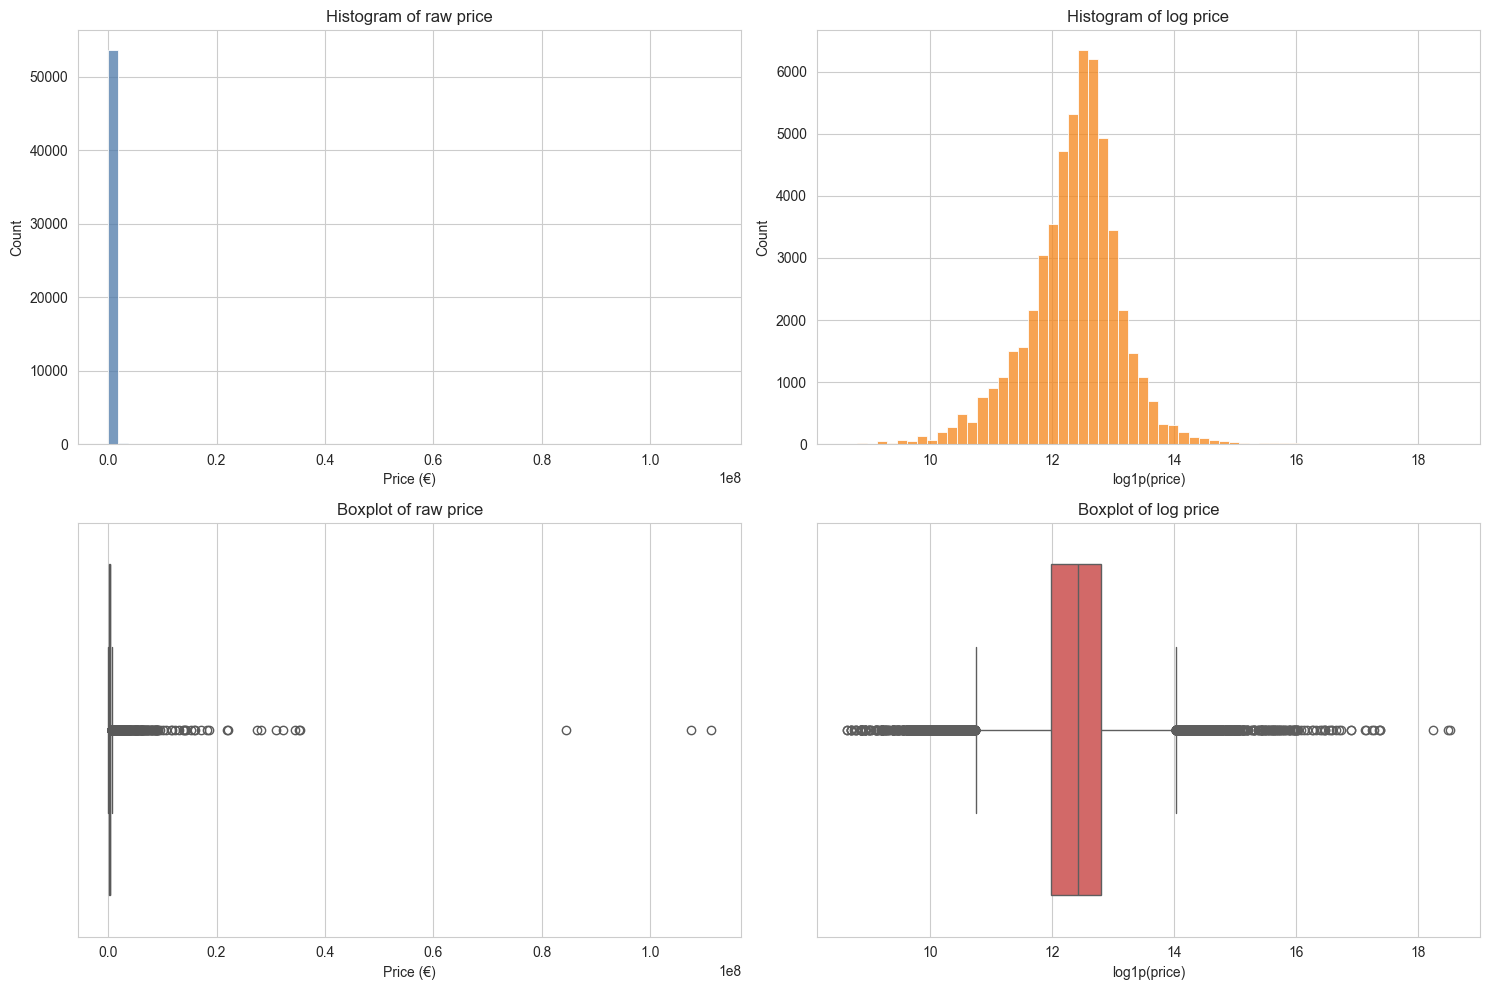

Top 20 highest prices


,Date of Sale (dd/mm/yyyy),County,Eircode_Routing,Address_clean,Price (€),log_price
36848,2022-09-16,Dublin,<NA>,DAVITT PRS DEVELOPMENT DAVITT ROAD DRIMNAGH,"111,280,172.00",18.53
31926,2021-12-22,Dublin,<NA>,ST CLARES PARK HAROLDS CROSS ROAD,"107,488,987.00",18.49
23067,2019-06-28,Dublin,D02,6 HANOVER QUAY DUBLIN 2,"84,420,800.00",18.25
42596,2023-11-29,Dublin,K36,MALAHIDE ROAD DUBLIN,"35,344,317.00",17.38
36614,2022-07-07,Cork,T12,APARTMENT BG 1 MELBOURN POINT BISHOPSTOWN,"35,178,712.00",17.38
22050,2019-08-01,Dublin,<NA>,A1 A7 A9 B1 27 C1 40 D1 23 RICHMOND GARDENS RI...,"34,515,141.00",17.36
45302,2023-07-07,Dublin,<NA>,DUNDRUM VIEW BALLINTEER ROAD DUNDRUM,"32,250,000.00",17.29
14496,2018-10-18,Dublin,<NA>,28 29 30 31 AND 32 GARDENS LANE 1 2 2 1 2 AND ...,"31,000,000.00",17.25
29221,2020-10-28,Dublin,<NA>,BLOCK E2 DUBLIN LANDINGS,"28,193,832.59",17.15
47975,2023-08-31,Dublin,<NA>,WILKINSON S BROOK HOLLYSTOWN,"27,519,823.79",17.13


Requested percentiles


,price
0.90,"525,000.00"
0.95,"700,000.00"
0.99,"1,452,407.11"
0.99,"2,167,400.88"
1.00,"6,896,229.18"


Extreme price flags


,count
above_99_5pct,271
is_extreme_price,54


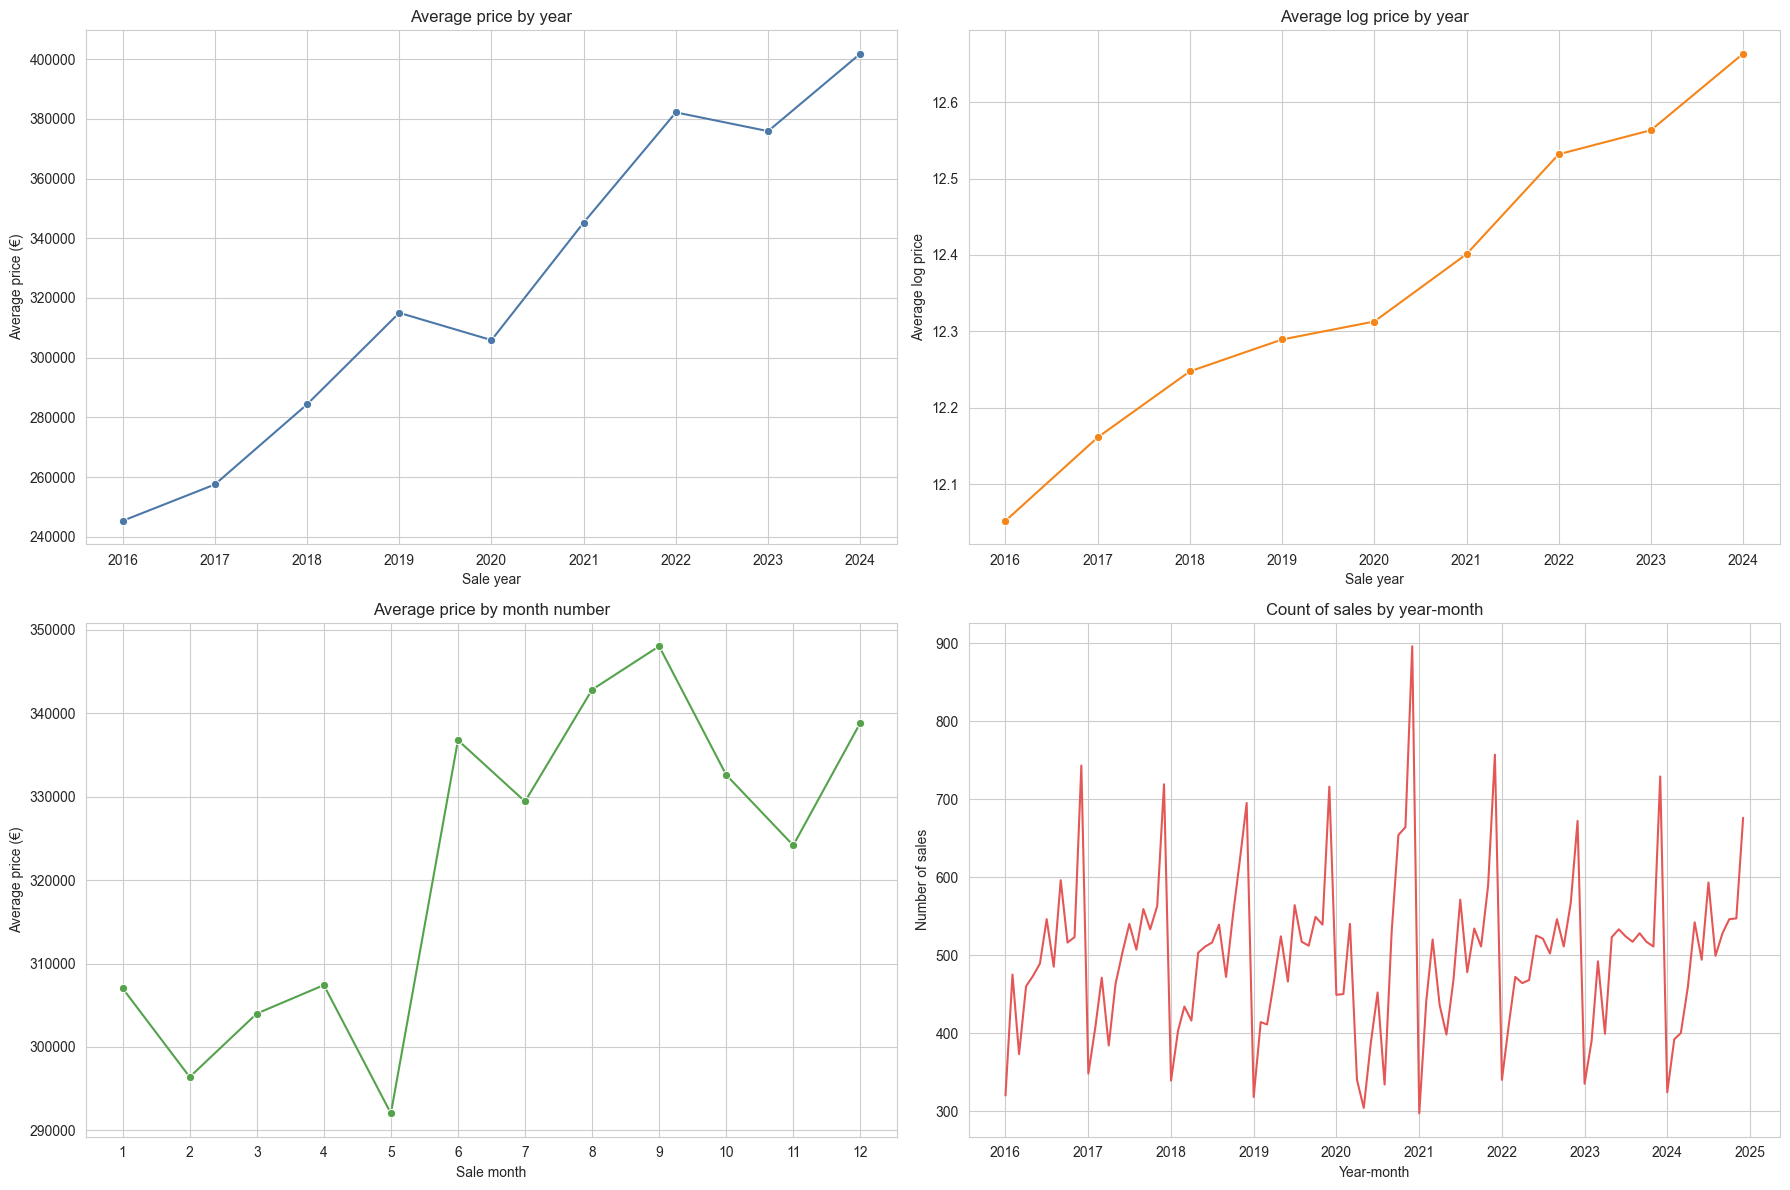

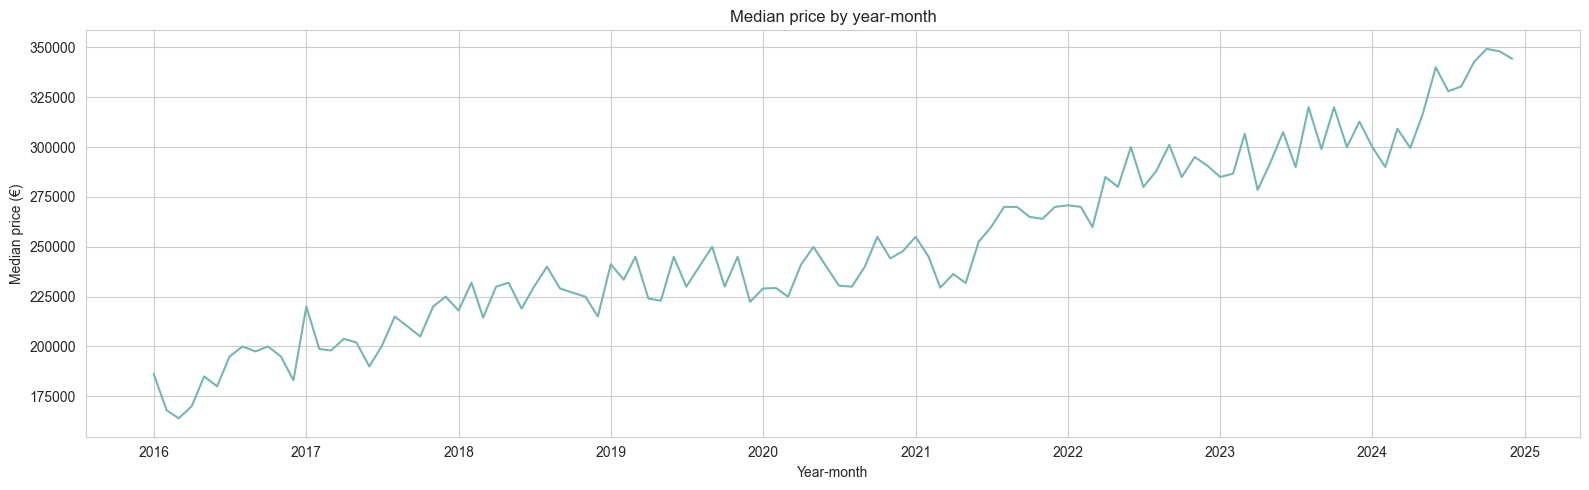

Month-to-month spread in average log price: 0.0970
Start-to-end change in average log price: 0.6110
Interpretation: the long-run time trend is stronger than the within-year seasonal pattern, so year and month index features are likely more important than pure seasonality alone.
Percent missing or unknown in area code: 32.62%
County frequency


,county_clean,count
0,Dublin,16358
1,Cork,5980
2,Kildare,3203
3,Galway,2582
4,Meath,2349
5,Limerick,2093
6,Wexford,1914
7,Wicklow,1799
8,Waterford,1546
9,Louth,1509


Area code frequency


,area_code_clean,count
0,UNKNOWN,17613
1,H91,1409
2,V94,1400
3,D15,1112
4,X91,984
5,A92,710
6,D24,671
7,W91,642
8,D08,604
9,D04,601


Top 20 area codes by count


,area_code_clean,count
0,UNKNOWN,17613
1,H91,1409
2,V94,1400
3,D15,1112
4,X91,984
5,A92,710
6,D24,671
7,W91,642
8,D08,604
9,D04,601


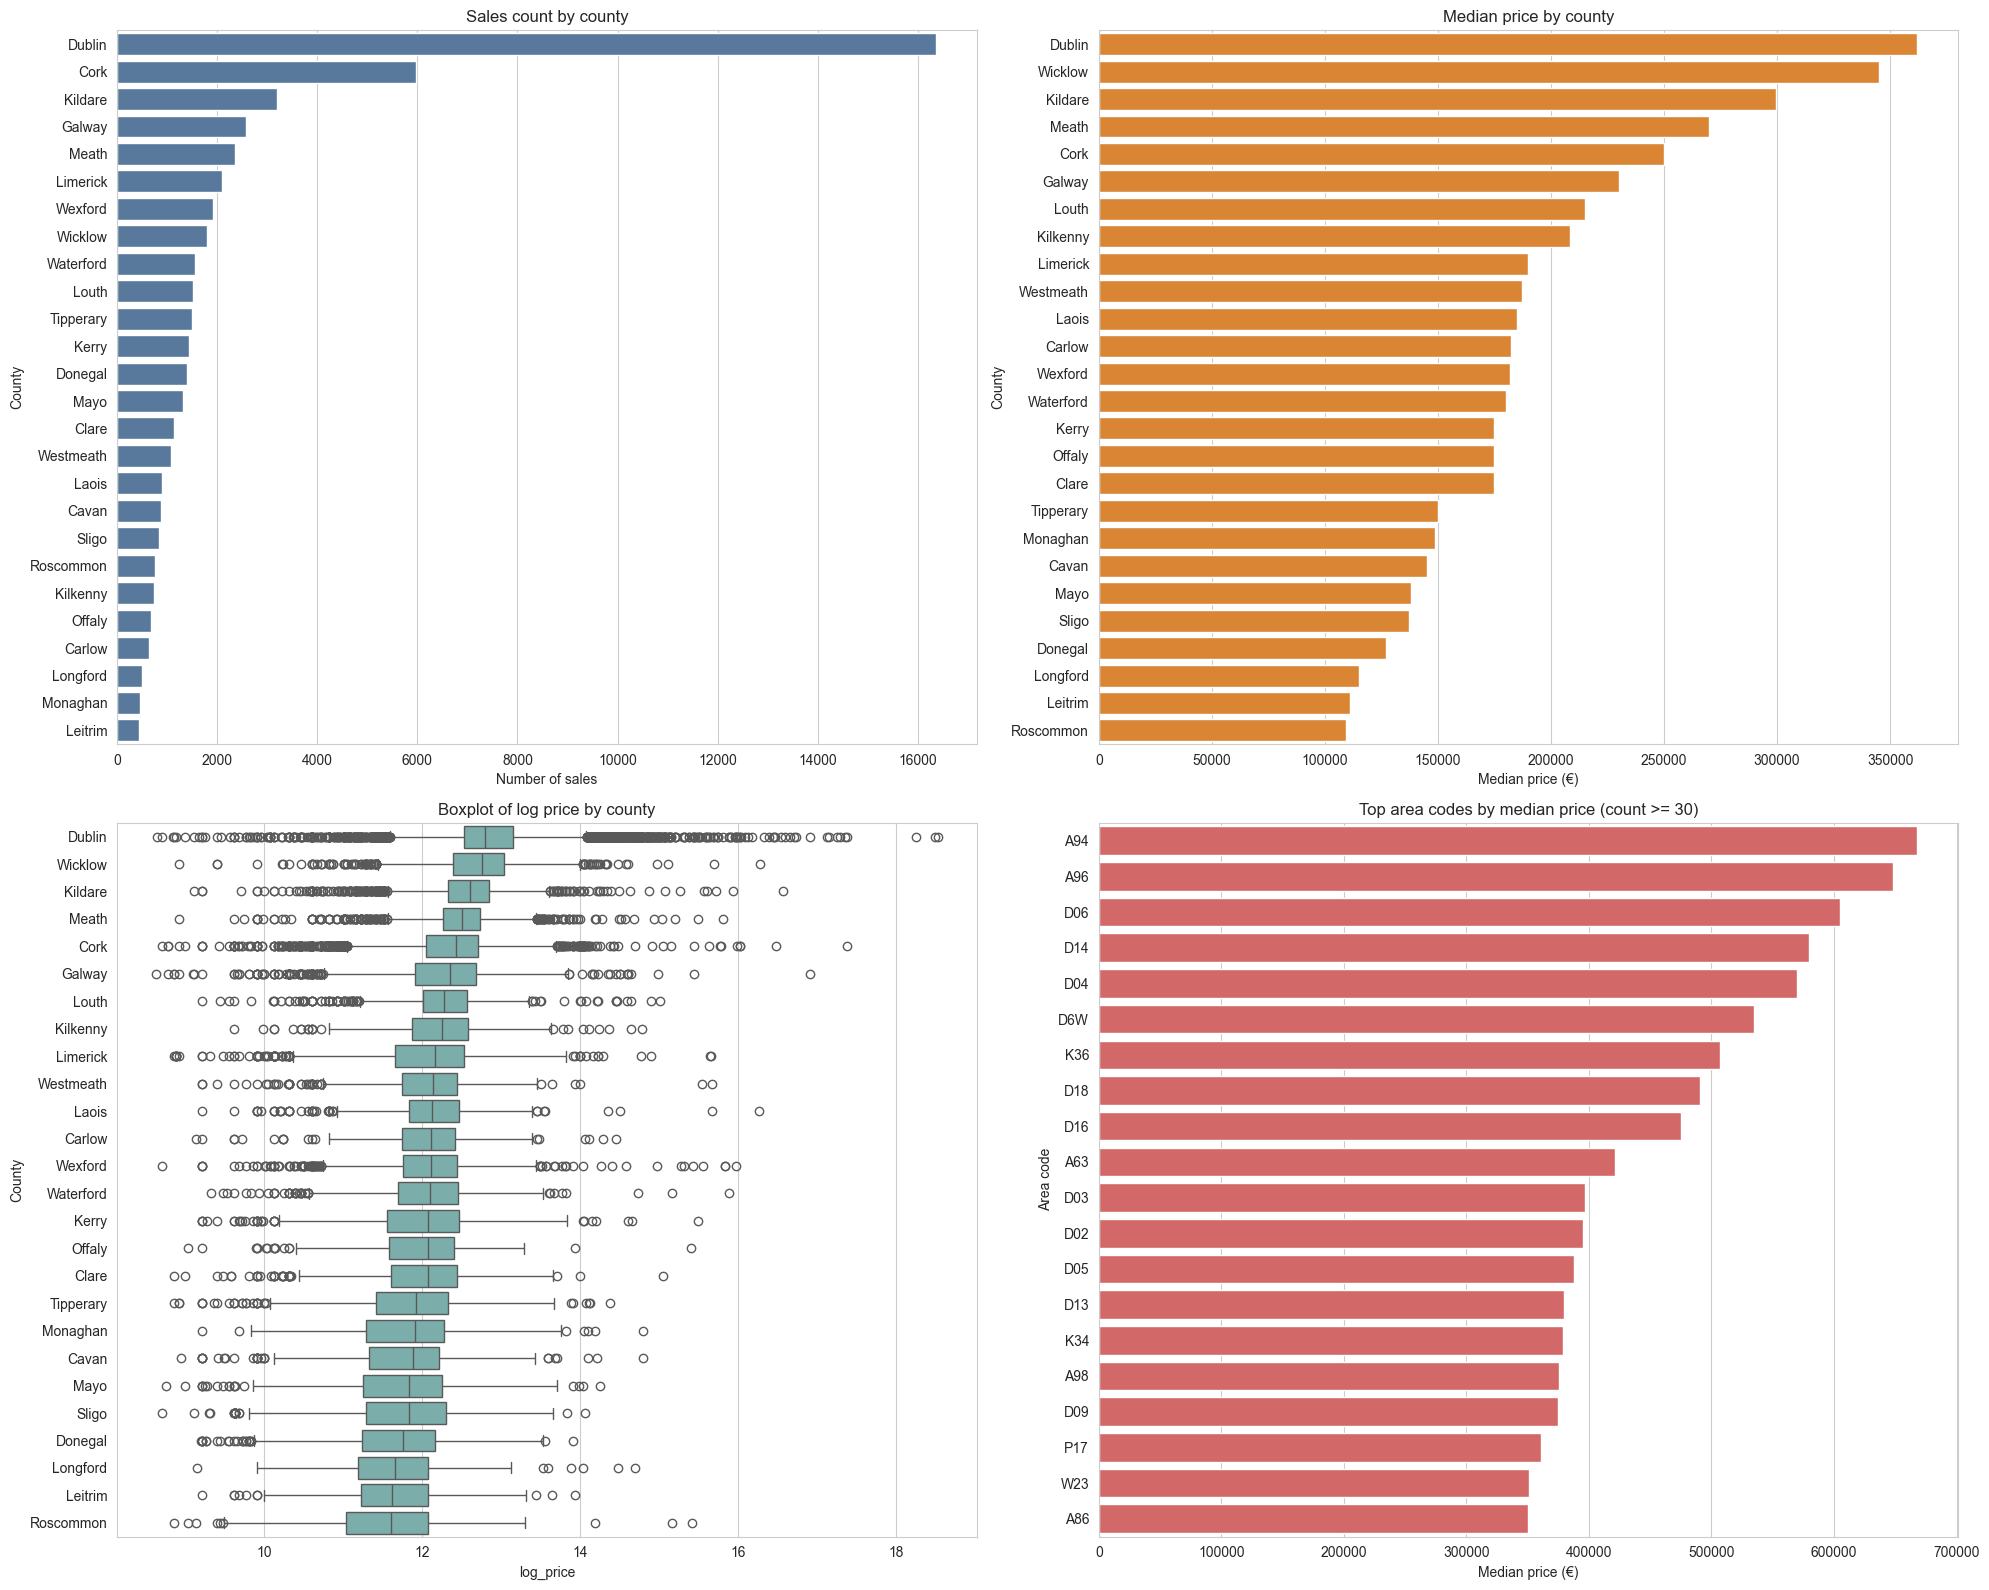

Known vs unknown area-code comparison


,count,mean,median
area_known,,,
Known,36379,12.41,12.47
Unknown,17613,12.26,12.36


Median log-price gap (Known - Unknown area code): 0.1054


In [25]:
def statistical_report(df):
    out = df.copy()
    price_col = 'Price (€)'
    date_col = 'Date of Sale (dd/mm/yyyy)'
    county_col = 'County'
    area_col = 'Eircode_Routing'
    address_col = 'Address_clean'

    out[price_col] = pd.to_numeric(out[price_col], errors='coerce')
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out = out.dropna(subset=[price_col, date_col]).copy()

    out['log_price'] = np.log1p(out[price_col])

    price_percentiles = out[price_col].quantile([0.90, 0.95, 0.99, 0.995, 0.999])
    p995 = price_percentiles.loc[0.995]
    p999 = price_percentiles.loc[0.999]

    out['above_99_5pct'] = (out[price_col] >= p995).astype('int8')
    out['is_extreme_price'] = (out[price_col] >= p999).astype('int8')

    out['sale_year'] = out[date_col].dt.year
    out['sale_month'] = out[date_col].dt.month
    out['sale_period'] = out[date_col].dt.to_period('M')
    out['sale_month_start'] = out['sale_period'].dt.to_timestamp()

    out['county_clean'] = out[county_col].fillna('Unknown').astype('string').str.strip()

    if area_col in out.columns:
        out['area_code_clean'] = (
            out[area_col]
            .fillna('Unknown')
            .astype('string')
            .str.upper()
            .str.strip()
        )
    else:
        out['area_code_clean'] = 'Unknown'

    out['area_code_missing'] = out['area_code_clean'].eq('UNKNOWN').astype('int8')
    out['address_text'] = out[address_col].astype('string').str.strip()

    target_stats = pd.DataFrame(
        {
            'price': out[price_col].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]),
            'log_price': out['log_price'].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]),
        }
    )
    display(target_stats)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    if USE_SEABORN:
        sns.histplot(out[price_col], bins=60, ax=axes[0, 0], color='#4C78A8')
        sns.histplot(out['log_price'], bins=60, ax=axes[0, 1], color='#F58518')
        sns.boxplot(x=out[price_col], ax=axes[1, 0], color='#72B7B2')
        sns.boxplot(x=out['log_price'], ax=axes[1, 1], color='#E45756')
    else:
        axes[0, 0].hist(out[price_col].dropna(), bins=60, color='#4C78A8')
        axes[0, 1].hist(out['log_price'].dropna(), bins=60, color='#F58518')
        axes[1, 0].boxplot(out[price_col].dropna(), vert=False)
        axes[1, 1].boxplot(out['log_price'].dropna(), vert=False)

    axes[0, 0].set_title('Histogram of raw price')
    axes[0, 0].set_xlabel('Price (€)')

    axes[0, 1].set_title('Histogram of log price')
    axes[0, 1].set_xlabel('log1p(price)')

    axes[1, 0].set_title('Boxplot of raw price')
    axes[1, 0].set_xlabel('Price (€)')

    axes[1, 1].set_title('Boxplot of log price')
    axes[1, 1].set_xlabel('log1p(price)')

    plt.tight_layout()
    plt.show()

    top_cols = [date_col, county_col, address_col, price_col, 'log_price']
    if area_col in out.columns:
        top_cols.insert(2, area_col)

    print('Top 20 highest prices')
    display(out.sort_values(price_col, ascending=False)[top_cols].head(20))

    print('Requested percentiles')
    display(price_percentiles.to_frame('price'))

    print('Extreme price flags')
    display(
        pd.DataFrame(
            {
                'count': [
                    int(out['above_99_5pct'].sum()),
                    int(out['is_extreme_price'].sum()),
                ]
            },
            index=['above_99_5pct', 'is_extreme_price'],
        )
    )

    yearly_summary = (
        out.groupby('sale_year')
        .agg(avg_price=(price_col, 'mean'), avg_log_price=('log_price', 'mean'))
        .reset_index()
    )

    month_number_summary = (
        out.groupby('sale_month')
        .agg(avg_price=(price_col, 'mean'), avg_log_price=('log_price', 'mean'))
        .reset_index()
    )

    period_summary = (
        out.groupby('sale_period')
        .agg(
            sales_count=(price_col, 'size'),
            median_price=(price_col, 'median'),
        )
        .reset_index()
    )
    period_summary['sale_month_start'] = period_summary['sale_period'].dt.to_timestamp()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    if USE_SEABORN:
        sns.lineplot(data=yearly_summary, x='sale_year', y='avg_price', marker='o', ax=axes[0, 0], color='#4C78A8')
        sns.lineplot(data=yearly_summary, x='sale_year', y='avg_log_price', marker='o', ax=axes[0, 1], color='#F58518')
        sns.lineplot(data=month_number_summary, x='sale_month', y='avg_price', marker='o', ax=axes[1, 0], color='#54A24B')
        sns.lineplot(data=period_summary, x='sale_month_start', y='sales_count', ax=axes[1, 1], color='#E45756')
    else:
        axes[0, 0].plot(yearly_summary['sale_year'], yearly_summary['avg_price'], marker='o', color='#4C78A8')
        axes[0, 1].plot(yearly_summary['sale_year'], yearly_summary['avg_log_price'], marker='o', color='#F58518')
        axes[1, 0].plot(month_number_summary['sale_month'], month_number_summary['avg_price'], marker='o', color='#54A24B')
        axes[1, 1].plot(period_summary['sale_month_start'], period_summary['sales_count'], color='#E45756')

    axes[0, 0].set_title('Average price by year')
    axes[0, 0].set_xlabel('Sale year')
    axes[0, 0].set_ylabel('Average price (€)')

    axes[0, 1].set_title('Average log price by year')
    axes[0, 1].set_xlabel('Sale year')
    axes[0, 1].set_ylabel('Average log price')

    axes[1, 0].set_title('Average price by month number')
    axes[1, 0].set_xlabel('Sale month')
    axes[1, 0].set_ylabel('Average price (€)')
    axes[1, 0].set_xticks(range(1, 13))

    axes[1, 1].set_title('Count of sales by year-month')
    axes[1, 1].set_xlabel('Year-month')
    axes[1, 1].set_ylabel('Number of sales')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(16, 5))
    if USE_SEABORN:
        sns.lineplot(data=period_summary, x='sale_month_start', y='median_price', color='#72B7B2')
    else:
        plt.plot(period_summary['sale_month_start'], period_summary['median_price'], color='#72B7B2')
    plt.title('Median price by year-month')
    plt.xlabel('Year-month')
    plt.ylabel('Median price (€)')
    plt.tight_layout()
    plt.show()

    seasonal_spread = month_number_summary['avg_log_price'].max() - month_number_summary['avg_log_price'].min()
    yearly_shift = yearly_summary['avg_log_price'].iloc[-1] - yearly_summary['avg_log_price'].iloc[0]

    print(f'Month-to-month spread in average log price: {seasonal_spread:.4f}')
    print(f'Start-to-end change in average log price: {yearly_shift:.4f}')

    if yearly_shift > seasonal_spread:
        print('Interpretation: the long-run time trend is stronger than the within-year seasonal pattern, so year and month index features are likely more important than pure seasonality alone.')
    else:
        print('Interpretation: the seasonal pattern is material enough to justify month and cyclical features alongside the year trend.')

    county_freq = (
        out['county_clean']
        .value_counts(dropna=False)
        .rename_axis('county_clean')
        .reset_index(name='count')
    )

    area_freq = (
        out['area_code_clean']
        .value_counts(dropna=False)
        .rename_axis('area_code_clean')
        .reset_index(name='count')
    )

    top_area_counts = area_freq.head(20)
    area_missing_pct = out['area_code_missing'].mean() * 100

    print(f'Percent missing or unknown in area code: {area_missing_pct:.2f}%')

    print('County frequency')
    display(county_freq)

    print('Area code frequency')
    display(area_freq.head(25))

    print('Top 20 area codes by count')
    display(top_area_counts)

    county_median_price = (
        out.groupby('county_clean')
        .agg(median_price=(price_col, 'median'), count=(price_col, 'size'))
        .sort_values('median_price', ascending=False)
        .reset_index()
    )

    area_price_summary = (
        out.loc[out['area_code_missing'] == 0]
        .groupby('area_code_clean')
        .agg(median_price=(price_col, 'median'), count=(price_col, 'size'))
        .query('count >= 30')
        .sort_values('median_price', ascending=False)
        .reset_index()
    )

    known_unknown_compare = (
        out.assign(area_known=np.where(out['area_code_missing'] == 1, 'Unknown', 'Known'))
        .groupby('area_known')['log_price']
        .agg(['count', 'mean', 'median'])
    )

    county_order = (
        out.groupby('county_clean')['log_price']
        .median()
        .sort_values(ascending=False)
        .index
    )

    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    if USE_SEABORN:
        sns.barplot(data=county_freq, y='county_clean', x='count', color='#4C78A8', ax=axes[0, 0])
        sns.barplot(data=county_median_price, y='county_clean', x='median_price', color='#F58518', ax=axes[0, 1])
        sns.boxplot(data=out, y='county_clean', x='log_price', order=county_order, ax=axes[1, 0], color='#72B7B2')
        sns.barplot(data=area_price_summary.head(20), y='area_code_clean', x='median_price', color='#E45756', ax=axes[1, 1])
    else:
        axes[0, 0].barh(county_freq['county_clean'], county_freq['count'], color='#4C78A8')
        axes[0, 1].barh(county_median_price['county_clean'], county_median_price['median_price'], color='#F58518')
        out.boxplot(column='log_price', by='county_clean', ax=axes[1, 0], vert=False)
        axes[1, 1].barh(area_price_summary.head(20)['area_code_clean'], area_price_summary.head(20)['median_price'], color='#E45756')

    axes[0, 0].set_title('Sales count by county')
    axes[0, 0].set_xlabel('Number of sales')
    axes[0, 0].set_ylabel('County')

    axes[0, 1].set_title('Median price by county')
    axes[0, 1].set_xlabel('Median price (€)')
    axes[0, 1].set_ylabel('County')

    axes[1, 0].set_title('Boxplot of log price by county')
    axes[1, 0].set_xlabel('log_price')
    axes[1, 0].set_ylabel('County')

    axes[1, 1].set_title('Top area codes by median price (count >= 30)')
    axes[1, 1].set_xlabel('Median price (€)')
    axes[1, 1].set_ylabel('Area code')

    plt.tight_layout()
    plt.show()

    print('Known vs unknown area-code comparison')
    display(known_unknown_compare)

    median_gap = (
        known_unknown_compare.loc['Known', 'median'] - known_unknown_compare.loc['Unknown', 'median']
        if {'Known', 'Unknown'}.issubset(known_unknown_compare.index)
        else np.nan
    )
    print(f'Median log-price gap (Known - Unknown area code): {median_gap:.4f}')

    return out

df_train = statistical_report(df_train)

## Step 6.5: Part 3 - Exploring Relationships Between Feature Pairs

This section focuses on a small set of promising feature-target relationships before adding the new engineered features from later steps.

The goal is to check whether location, sale timing, and dwelling type appear predictive of `log_price`, and to summarise the story of the data in a way that directly supports the modelling decisions in later sections.

,log_price,Is_Second_Hand,area_code_missing,sale_year,sale_month
log_price,1.00,-0.16,-0.09,0.24,0.04
Is_Second_Hand,-0.16,1.00,-0.27,-0.04,-0.05
area_code_missing,-0.09,-0.27,1.00,-0.26,-0.01
sale_year,0.24,-0.04,-0.26,1.00,-0.01
sale_month,0.04,-0.05,-0.01,-0.01,1.00


,dwelling_type,count,median,mean
0,New,9588,12.64,12.63
1,Second-hand,44404,12.37,12.30


,area_known_flag,count,median,mean
0,Known area code,36379,12.47,12.41
1,Unknown area code,17613,12.36,12.26


,county_clean,count,median
0,Dublin,16358,12.80
1,Wicklow,1799,12.75
2,Kildare,3203,12.61
3,Meath,2349,12.51
4,Cork,5980,12.43
5,Galway,2582,12.35
6,Louth,1509,12.28
7,Kilkenny,740,12.25
8,Limerick,2093,12.15
9,Westmeath,1083,12.14


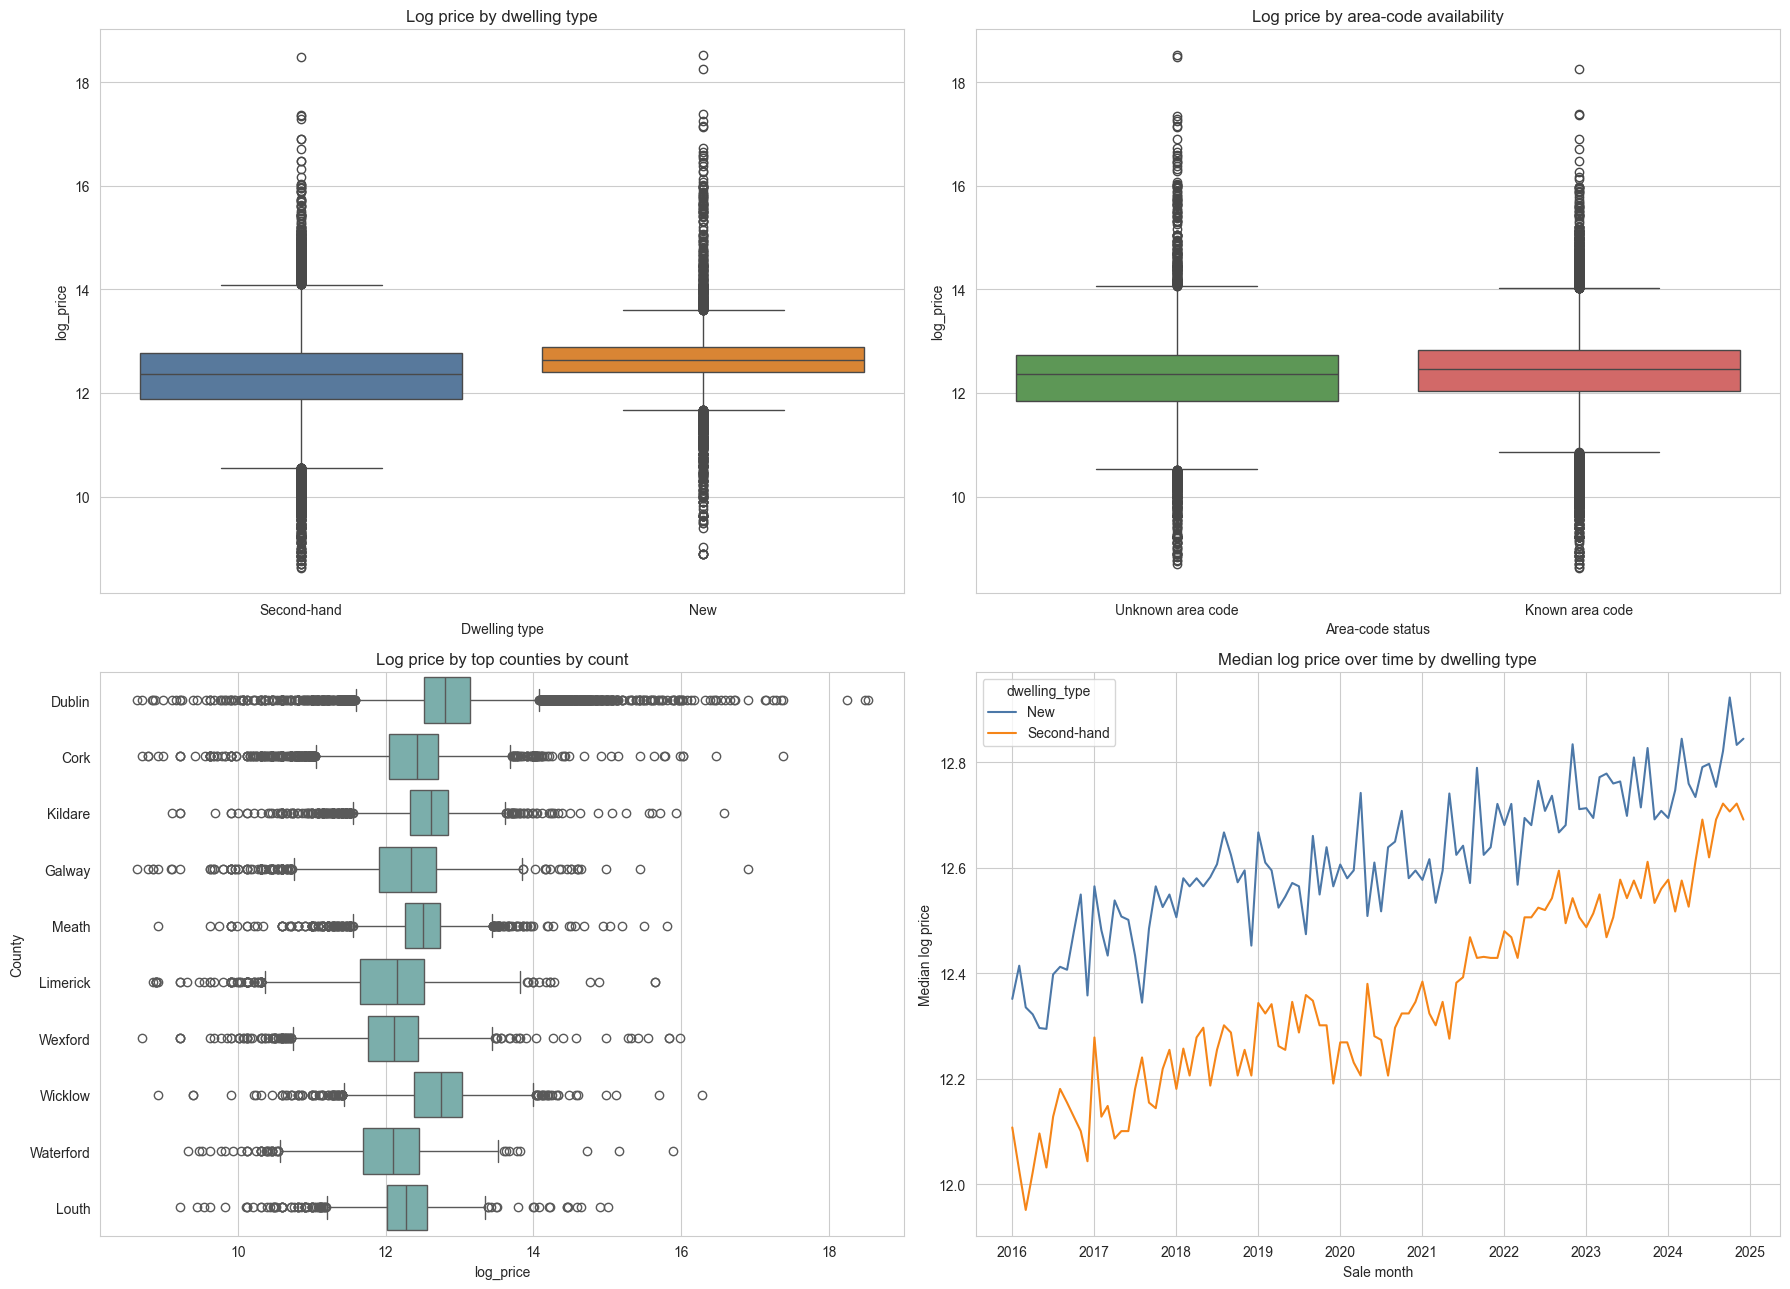

Interpretation summary:
- Dwelling type shows a visible price-level difference, so second-hand versus new is a useful predictive feature.
- Known routing-key information is associated with a different price distribution from unknown routing-key cases, which supports keeping location quality signals.
- County-level price distributions differ substantially, confirming that geography is one of the strongest drivers of property value.
- The time plot suggests that the price level changes over the year and differs by dwelling type, so time features are justified in the later model.


In [36]:
def analyse_feature_pairs(df):
    out = df.copy()

    required_cols = [
        'log_price',
        'Is_Second_Hand',
        'county_clean',
        'area_code_clean',
        'area_code_missing',
        'sale_month_start',
    ]
    missing_cols = [col for col in required_cols if col not in out.columns]
    if missing_cols:
        raise ValueError(f'Missing columns for pairwise analysis: {missing_cols}')

    out['county_clean'] = out['county_clean'].astype('string').fillna('Unknown').str.strip()
    out['area_code_clean'] = out['area_code_clean'].astype('string').fillna('Unknown').str.strip()
    out['area_known_flag'] = np.where(out['area_code_missing'] == 1, 'Unknown area code', 'Known area code')
    out['dwelling_type'] = np.where(out['Is_Second_Hand'] == 1, 'Second-hand', 'New')

    pairwise_numeric = out[[
        'log_price',
        'Is_Second_Hand',
        'area_code_missing',
        'sale_year',
        'sale_month',
    ]].copy()
    pairwise_corr = pairwise_numeric.corr(numeric_only=True).round(3)

    top_counties = (
        out['county_clean']
        .value_counts()
        .head(10)
        .index
    )
    county_plot_df = out[out['county_clean'].isin(top_counties)].copy()

    median_by_type = (
        out.groupby('dwelling_type')['log_price']
        .agg(['count', 'median', 'mean'])
        .round(3)
        .reset_index()
    )

    median_by_area_known = (
        out.groupby('area_known_flag')['log_price']
        .agg(['count', 'median', 'mean'])
        .round(3)
        .reset_index()
    )

    county_summary = (
        out.groupby('county_clean')['log_price']
        .agg(['count', 'median'])
        .sort_values(['median', 'count'], ascending=[False, False])
        .reset_index()
    )

    monthly_type_summary = (
        out.groupby(['sale_month_start', 'dwelling_type'])['log_price']
        .median()
        .reset_index()
    )

    display(pairwise_corr)
    display(median_by_type)
    display(median_by_area_known)
    display(county_summary.head(15))

    fig, axes = plt.subplots(2, 2, figsize=(18, 13))

    if USE_SEABORN:
        sns.boxplot(data=out, x='dwelling_type', y='log_price', ax=axes[0, 0], palette=['#4C78A8', '#F58518'])
        sns.boxplot(data=out, x='area_known_flag', y='log_price', ax=axes[0, 1], palette=['#54A24B', '#E45756'])
        sns.boxplot(data=county_plot_df, y='county_clean', x='log_price', order=top_counties, ax=axes[1, 0], color='#72B7B2')
        sns.lineplot(data=monthly_type_summary, x='sale_month_start', y='log_price', hue='dwelling_type', ax=axes[1, 1], palette=['#4C78A8', '#F58518'])
    else:
        out.boxplot(column='log_price', by='dwelling_type', ax=axes[0, 0])
        out.boxplot(column='log_price', by='area_known_flag', ax=axes[0, 1])
        county_plot_df.boxplot(column='log_price', by='county_clean', ax=axes[1, 0], vert=False)
        for dwelling_type, group_df in monthly_type_summary.groupby('dwelling_type'):
            axes[1, 1].plot(group_df['sale_month_start'], group_df['log_price'], label=dwelling_type)
        axes[1, 1].legend()

    axes[0, 0].set_title('Log price by dwelling type')
    axes[0, 0].set_xlabel('Dwelling type')
    axes[0, 0].set_ylabel('log_price')

    axes[0, 1].set_title('Log price by area-code availability')
    axes[0, 1].set_xlabel('Area-code status')
    axes[0, 1].set_ylabel('log_price')

    axes[1, 0].set_title('Log price by top counties by count')
    axes[1, 0].set_xlabel('log_price')
    axes[1, 0].set_ylabel('County')

    axes[1, 1].set_title('Median log price over time by dwelling type')
    axes[1, 1].set_xlabel('Sale month')
    axes[1, 1].set_ylabel('Median log price')

    if not USE_SEABORN:
        plt.suptitle('')

    plt.tight_layout()
    plt.show()

    print('Interpretation summary:')
    print('- Dwelling type shows a visible price-level difference, so second-hand versus new is a useful predictive feature.')
    print('- Known routing-key information is associated with a different price distribution from unknown routing-key cases, which supports keeping location quality signals.')
    print('- County-level price distributions differ substantially, confirming that geography is one of the strongest drivers of property value.')
    print('- The time plot suggests that the price level changes over the year and differs by dwelling type, so time features are justified in the later model.')

    return {
        'pairwise_corr': pairwise_corr,
        'median_by_type': median_by_type,
        'median_by_area_known': median_by_area_known,
        'county_summary': county_summary,
        'monthly_type_summary': monthly_type_summary,
    }


pairwise_results = analyse_feature_pairs(df_train)

The pairwise plots show a consistent story. Geography appears to be the strongest signal, because counties have clearly different log-price distributions and known routing-key information separates transactions better than unknown locations. Dwelling type also matters, with new and second-hand properties following different price levels. Finally, the monthly median log-price trends suggest that time features are not just technical additions but reflect a real shift in market level over time.

## Step 7: Internal Feature Engineering

In [26]:
# Here we create the address-based text features.
# These are simple flags from the address itself, so they are safe to create
# on both train and test because they do not use the target price.
def add_address_features(df, address_col='address_text'):
    out = df.copy()

    # If the address column is missing, we still create the output columns
    # so that the rest of the pipeline keeps the same structure.
    if address_col not in out.columns:
        out['is_apartment_text'] = np.nan
        out['has_estate_term'] = np.nan
        out['has_rural_term'] = np.nan
        out['has_house_number'] = np.nan
        out['address_token_count'] = np.nan
        return out

    # Clean the address into lowercase text so pattern matching is consistent.
    address_text = out[address_col].astype('string').fillna('').str.lower()

    # Flag whether the address looks like an apartment-style property.
    out['is_apartment_text'] = address_text.str.contains(
        r'\b(apt|apartment|flat|unit|suite|duplex|penthouse)\b',
        regex=True,
    ).astype('int8')

    # Flag whether the address contains estate-style housing terms.
    out['has_estate_term'] = address_text.str.contains(
        r'\b(estate|manor|park|court|view|close|gardens?|grange|woods?|heights?|green|lawns?|crescent|villas?)\b',
        regex=True,
    ).astype('int8')

    # Flag whether the address contains rural-style location terms.
    out['has_rural_term'] = address_text.str.contains(
        r'\b(road|rd|lane|ln|cross|upper|lower|townland|farm|west|east|north|south|bally|kil|mount)\b',
        regex=True,
    ).astype('int8')

    # Flag whether the address seems to include a house number.
    out['has_house_number'] = address_text.str.contains(
        r'(^|\s)(no\.?\s*)?\d+[a-z]?(\s|,|$)',
        regex=True,
    ).astype('int8')

    # Count how many tokens are in the address as a simple text-length feature.
    out['address_token_count'] = address_text.str.split().str.len().fillna(0).astype('int16')

    return out


# Here we build a full month-by-month grid for each group.
# This is needed so the trailing windows can continue forward into future test months.
def complete_group_month_grid(monthly_df, group_col, period_col='sale_period', end_period=None):
    if monthly_df.empty:
        return monthly_df.copy()

    # Start at the first month where we have history and continue up to the final month we need.
    start_period = monthly_df[period_col].min()
    final_period = end_period if end_period is not None else monthly_df[period_col].max()
    full_periods = pd.period_range(start_period, final_period, freq='M')

    frames = []
    for group_value, group_df in monthly_df.groupby(group_col):
        expanded = group_df.set_index(period_col).reindex(full_periods)
        expanded[group_col] = group_value
        expanded.index.name = period_col
        frames.append(expanded.reset_index())

    return pd.concat(frames, ignore_index=True)


# Here we create trailing median log-price features by county or by area code.
# The key rule is:
# - for train rows, reference_df should be train itself
# - for hidden test rows, reference_df must still be the train data only
# This avoids leaking unknown test prices into the features.
def add_trailing_price_features(
    base_df,
    reference_df,
    group_col,
    prefix,
    end_period=None,
    windows=(6, 12),
    min_history=None,
):
    out = base_df.copy()

    if min_history is None:
        # Require a little history before we trust the rolling value.
        min_history = {6: 3, 12: 6}

    feature_names = [f'{prefix}_trailing_{window}m_median_log_price' for window in windows]

    # If the reference data does not have the required columns, create empty features.
    required = {group_col, 'sale_period', 'log_price'}
    if not required.issubset(reference_df.columns):
        for feature_name in feature_names:
            out[feature_name] = np.nan
        return out

    ref = reference_df.copy()

    # Keep only rows where the group, month, and log price are known.
    ref = ref[ref[group_col].notna() & ref['sale_period'].notna() & ref['log_price'].notna()]

    # Unknown area codes are not useful for area-level rolling history.
    if group_col == 'area_code_clean':
        ref = ref[ref[group_col] != 'Unknown']

    # Collapse the reference data to one median log price per group and month.
    monthly = (
        ref.groupby([group_col, 'sale_period'])['log_price']
        .median()
        .rename('monthly_group_median_log_price')
        .reset_index()
    )

    if monthly.empty:
        for feature_name in feature_names:
            out[feature_name] = np.nan
        return out

    # Expand the monthly history forward to the last month we need.
    expanded = complete_group_month_grid(
        monthly,
        group_col=group_col,
        end_period=end_period,
    )

    # Build trailing windows using shift(1) so the current month never sees its own target.
    for window in windows:
        feature_name = f'{prefix}_trailing_{window}m_median_log_price'
        expanded[feature_name] = expanded.groupby(group_col)['monthly_group_median_log_price'].transform(
            lambda s: s.shift(1).rolling(window, min_periods=min_history.get(window, 1)).median()
        )

    # Merge the finished rolling features back onto the base dataframe.
    merge_cols = [group_col, 'sale_period'] + feature_names
    out = out.merge(expanded[merge_cols], on=[group_col, 'sale_period'], how='left')

    # For missing/unknown area codes, area-level trailing values should stay empty.
    if group_col == 'area_code_clean' and 'area_code_missing' in out.columns:
        out.loc[out['area_code_missing'] == 1, feature_names] = np.nan

    return out


# Here we put the whole of Step 7 into one reusable function.
# It can work on both train and test:
# - if is_train=True, it uses the dataframe itself as the price history
# - if is_train=False, it uses history_df, which should be the processed train dataframe
def step7_add_features(
    df,
    history_df=None,
    is_train=True,
    price_col='Price (€)',
    date_col='Date of Sale (dd/mm/yyyy)',
    county_col='County',
    address_col='Address',
    area_col='Eircode_Routing',
):
    out = df.copy()

    # First make sure the time and grouping columns exist in a consistent format.
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out['sale_period'] = out[date_col].dt.to_period('M')

    out['county_clean'] = out[county_col].fillna('Unknown').astype('string').str.strip()

    if area_col in out.columns:
        out['area_code_clean'] = (
            out[area_col]
            .fillna('Unknown')
            .astype('string')
            .str.upper()
            .str.strip()
        )
    else:
        out['area_code_clean'] = 'Unknown'

    out['area_code_missing'] = out['area_code_clean'].eq('UNKNOWN').astype('int8')
    out['address_text'] = out[address_col].astype('string').str.strip()

    # Add the text features from address.
    out = add_address_features(out, address_col='address_text')

    # Train rows are allowed to create log_price because the target is known there.
    if is_train:
        out[price_col] = pd.to_numeric(out[price_col], errors='coerce')
        out['log_price'] = np.log1p(out[price_col])
        history = out.copy()
    else:
        # For hidden test rows we must use train history only.
        if history_df is None:
            raise ValueError("When is_train=False, you must pass the processed training dataframe as history_df.")
        history = history_df.copy()

    # Make sure the history dataframe also has the same key helper columns.
    if 'sale_period' not in history.columns:
        history[date_col] = pd.to_datetime(history[date_col], errors='coerce')
        history['sale_period'] = history[date_col].dt.to_period('M')

    if 'county_clean' not in history.columns:
        history['county_clean'] = history[county_col].fillna('Unknown').astype('string').str.strip()

    if 'area_code_clean' not in history.columns:
        if area_col in history.columns:
            history['area_code_clean'] = (
                history[area_col]
                .fillna('Unknown')
                .astype('string')
                .str.upper()
                .str.strip()
            )
        else:
            history['area_code_clean'] = 'Unknown'

    if 'area_code_missing' not in history.columns:
        history['area_code_missing'] = history['area_code_clean'].eq('UNKNOWN').astype('int8')

    if 'address_text' not in history.columns:
        history['address_text'] = history[address_col].astype('string').str.strip()

    # If log_price is not already present in the history dataframe, create it from the known train prices.
    if 'log_price' not in history.columns:
        if price_col not in history.columns:
            raise ValueError("history_df must contain either log_price or the price column.")
        history[price_col] = pd.to_numeric(history[price_col], errors='coerce')
        history['log_price'] = np.log1p(history[price_col])

    # We expand rolling history up to the furthest month seen in either the base or the history data.
    end_period = max(out['sale_period'].max(), history['sale_period'].max())

    # Add county-level trailing price history.
    out = add_trailing_price_features(
        out,
        reference_df=history,
        group_col='county_clean',
        prefix='county',
        end_period=end_period,
        windows=(6, 12),
    )

    # Add area-code-level trailing price history.
    out = add_trailing_price_features(
        out,
        reference_df=history,
        group_col='area_code_clean',
        prefix='area',
        end_period=end_period,
        windows=(6, 12),
    )

    return out

df_train = step7_add_features(df_train, history_df=df_train, is_train=True)

In [27]:
display(quality_overview(df_train))


,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,dtype,missing_count,missing_%,nunique_including_nan
Property Size Description,category,51217,94.86,5
Eircode,category,37091,68.70,16850
Eircode_Routing_Inferred,object,24435,45.26,127
area_trailing_12m_median_log_price,float64,20580,38.12,4397
area_trailing_6m_median_log_price,float64,19627,36.35,5726
Eircode_Routing,string,17613,32.62,140
county_trailing_12m_median_log_price,float64,2608,4.83,1341
county_trailing_6m_median_log_price,float64,1181,2.19,1755
row_id,int64,0,0.00,53992
Address,string,0,0.00,53315


(None, None, None)

We have added a lot of features from within the dataset, of which we will keep from modeling

## Step 8: External Feature Engineering

In [28]:
# Step 8 keeps the external-data merges in one reusable function so the same logic can be applied to train and test.
# It expects Step 5 to have been run already, because that step builds the routing-key county lookup we reuse here.
def prepare_external_merge_keys(
    df,
    area_county,
    county_col='County',
    area_col='Eircode_Routing',
    date_col='Date of Sale (dd/mm/yyyy)',
):
    out = df.copy()

    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')

    if 'Year' not in out.columns:
        out['Year'] = out[date_col].dt.year
    if 'Month' not in out.columns:
        out['Month'] = out[date_col].dt.month

    out['Quarter'] = (((out['Month'] - 1) // 3) + 1).astype('Int64')

    # Build a standard area-code key.
    if 'Area Code' in out.columns:
        area_code = out['Area Code']
    elif 'area_code_clean' in out.columns:
        area_code = out['area_code_clean']
    elif area_col in out.columns:
        area_code = out[area_col]
    else:
        area_code = pd.Series(pd.NA, index=out.index, dtype='string')

    out['Area Code'] = area_code.astype('string').str.upper().str.strip()
    out['Area Code'] = out['Area Code'].replace({'UNKNOWN': pd.NA, 'Unknown': pd.NA, '': pd.NA})

    # Build a standard county key from the original data first.
    if 'County_Clean' in out.columns:
        county_clean = out['County_Clean']
    elif 'county_clean' in out.columns:
        county_clean = out['county_clean']
    else:
        county_clean = out[county_col]

    out['County_Clean'] = county_clean.astype('string').str.strip()
    out = out.drop(columns=['County_Area'], errors='ignore')

    # Merge only the safe unique routing-key county lookup.
    county_lookup = area_county.copy()
    county_lookup['Eircode3'] = county_lookup['Eircode3'].astype('string').str.upper().str.strip()
    county_lookup['County'] = county_lookup['County'].astype('string').str.strip()

    out = out.merge(
        county_lookup.rename(columns={'Eircode3': 'Area Code', 'County': 'County_Area'}),
        on='Area Code',
        how='left',
    )

    # Important:
    # keep the original county where it already exists, and only fill missing county values
    # from the routing-key lookup. This avoids forcing ambiguous routing keys into a wrong county.
    out['County_Clean'] = out['County_Clean'].fillna(out['County_Area'])

    # Create lagged merge keys for external datasets.
    # Population is annual, so use previous year.
    out['Population_Year'] = (pd.to_numeric(out['Year'], errors='coerce') - 1).astype('Int64')

    # Dwellings is quarterly, so use previous quarter.
    out['Dwellings_Year'] = pd.to_numeric(out['Year'], errors='coerce').astype('Int64')
    out['Dwellings_Quarter'] = out['Quarter'].astype('Int64')

    q1_mask = out['Dwellings_Quarter'] == 1
    out.loc[q1_mask, 'Dwellings_Quarter'] = 4
    out.loc[q1_mask, 'Dwellings_Year'] = out.loc[q1_mask, 'Dwellings_Year'] - 1
    out.loc[~q1_mask, 'Dwellings_Quarter'] = out.loc[~q1_mask, 'Dwellings_Quarter'] - 1

    return out


def merge_dwellings(df, area_county, dwellings_path='external_datasets/new_dwellings_by_area_code.csv'):
    out = df.copy()

    try:
        df_dwellings = pd.read_csv(dwellings_path)
    except FileNotFoundError:
        for col in ['County_New_Dwellings', 'Area_New_Dwellings']:
            if col not in out.columns:
                out[col] = np.nan
        print(f'External dataset not found: {dwellings_path}. Leaving dwelling features as NaN.')
        return out

    df_dwellings['Area Code'] = df_dwellings['Eircode Output'].astype('string').str[:3].str.upper().str.strip()

    quarter_parts = df_dwellings['Quarter'].astype('string').str.extract(
        r'(?P<Year>\d{4})Q(?P<Quarter>\d)'
    )
    df_dwellings['Year'] = pd.to_numeric(quarter_parts['Year'], errors='coerce').astype('Int64')
    df_dwellings['Quarter'] = pd.to_numeric(quarter_parts['Quarter'], errors='coerce').astype('Int64')
    df_dwellings['VALUE'] = pd.to_numeric(df_dwellings['VALUE'], errors='coerce')

    area_dwellings = (
        df_dwellings[['Area Code', 'Year', 'Quarter', 'VALUE']]
        .rename(
            columns={
                'Year': 'Dwellings_Year',
                'Quarter': 'Dwellings_Quarter',
                'VALUE': 'Area_New_Dwellings',
            }
        )
        .dropna(subset=['Area Code', 'Dwellings_Year', 'Dwellings_Quarter'])
    )

    county_lookup = area_county.copy()
    county_lookup['Eircode3'] = county_lookup['Eircode3'].astype('string').str.upper().str.strip()
    county_lookup['County'] = county_lookup['County'].astype('string').str.strip()

    area_dwellings_with_county = area_dwellings.merge(
        county_lookup.rename(columns={'Eircode3': 'Area Code', 'County': 'County_Clean'}),
        on='Area Code',
        how='left',
    )

    county_dwellings = (
        area_dwellings_with_county
        .dropna(subset=['County_Clean'])
        .groupby(['County_Clean', 'Dwellings_Year', 'Dwellings_Quarter'], as_index=False)['Area_New_Dwellings']
        .sum()
        .rename(columns={'Area_New_Dwellings': 'County_New_Dwellings'})
    )

    out = out.drop(columns=['County_New_Dwellings', 'Area_New_Dwellings'], errors='ignore')

    out = out.merge(
        county_dwellings,
        on=['County_Clean', 'Dwellings_Year', 'Dwellings_Quarter'],
        how='left',
    )

    out = out.merge(
        area_dwellings[['Area Code', 'Dwellings_Year', 'Dwellings_Quarter', 'Area_New_Dwellings']],
        on=['Area Code', 'Dwellings_Year', 'Dwellings_Quarter'],
        how='left',
    )

    return out


def merge_mortgage(df, mortgage_path='external_datasets/mortgage_interest_by_year_month.csv'):
    out = df.copy()

    try:
        df_mortgage = pd.read_csv(mortgage_path)
    except FileNotFoundError:
        if 'Mortgage Interest Rate' not in out.columns:
            out['Mortgage Interest Rate'] = np.nan
        print(f'External dataset not found: {mortgage_path}. Leaving mortgage features as NaN.')
        return out

    month_parts = df_mortgage['Month'].astype('string').str.extract(
        r'(?P<Year>\d{4})\s+(?P<Month_Name>[A-Za-z]+)'
    )
    month_mapping = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
        'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12,
    }

    df_mortgage['Year'] = pd.to_numeric(month_parts['Year'], errors='coerce').astype('Int64')
    df_mortgage['Month'] = month_parts['Month_Name'].map(month_mapping).astype('Int64')
    df_mortgage['VALUE'] = pd.to_numeric(df_mortgage['VALUE'], errors='coerce')

    df_mortgage = df_mortgage[['Year', 'Month', 'VALUE']].rename(columns={'VALUE': 'Mortgage Interest Rate'})

    out = out.drop(columns=['Mortgage Interest Rate'], errors='ignore')
    out = out.merge(df_mortgage, on=['Year', 'Month'], how='left')
    return out


def merge_population(df, population_path='external_datasets/population.csv'):
    out = df.copy()

    try:
        df_population = pd.read_csv(population_path)
    except FileNotFoundError:
        if 'Population' not in out.columns:
            out['Population'] = np.nan
        print(f'External dataset not found: {population_path}. Leaving population as NaN.')
        return out

    df_population['County'] = (
        df_population['County']
        .astype('string')
        .str.replace('Co. ', '', regex=False)
        .str.strip()
    )
    df_population['Year'] = pd.to_numeric(df_population['Year'], errors='coerce').astype('Int64')
    df_population['VALUE'] = pd.to_numeric(df_population['VALUE'], errors='coerce')

    df_population = (
        df_population[['County', 'Year', 'VALUE']]
        .rename(
            columns={
                'County': 'County_Clean',
                'Year': 'Population_Year',
                'VALUE': 'Population',
            }
        )
    )

    out = out.drop(columns=['Population'], errors='ignore')
    out = out.merge(df_population, on=['County_Clean', 'Population_Year'], how='left')
    return out


def merge_area_size_and_density(
    df,
    area_county,
    shape_path='external_datasets/routingkeys_shape_itm_2016_09_29/RoutingKeys_ITM_region.shp',
):
    import geopandas as gpd

    out = df.copy()

    # Read routing-key polygons
    gdf = gpd.read_file(shape_path)

    # First inspect this once to confirm the routing-key column name
    # print(gdf.columns)

    # Replace ROUTING_KEY_COL with the real shapefile column after inspection
    ROUTING_KEY_COL = 'RoutingKey'

    gdf[ROUTING_KEY_COL] = (
        gdf[ROUTING_KEY_COL]
        .astype('string')
        .str.upper()
        .str.strip()
    )

    # ITM coordinates are in metres, so geometry.area gives m^2
    gdf['Area_km2'] = gdf.geometry.area / 1_000_000

    area_size = (
        gdf[[ROUTING_KEY_COL, 'Area_km2']]
        .rename(columns={ROUTING_KEY_COL: 'Area Code', 'Area_km2': 'Area_km2'})
        .dropna(subset=['Area Code'])
        .groupby('Area Code', as_index=False)['Area_km2']
        .sum()
    )

    out = out.drop(columns=['Area_km2', 'County_Area_km2'], errors='ignore')
    out = out.merge(area_size, on='Area Code', how='left')

    # County area from unique routing-key -> county mapping only
    county_lookup = area_county.copy()
    county_lookup['Eircode3'] = county_lookup['Eircode3'].astype('string').str.upper().str.strip()
    county_lookup['County'] = county_lookup['County'].astype('string').str.strip()

    county_area = (
        area_size.merge(
            county_lookup.rename(columns={'Eircode3': 'Area Code', 'County': 'County_Clean'}),
            on='Area Code',
            how='inner'
        )
        .groupby('County_Clean', as_index=False)['Area_km2']
        .sum()
        .rename(columns={'Area_km2': 'County_Area_km2'})
    )

    out = out.merge(county_area, on='County_Clean', how='left')

    # Density features
    if 'Population' in out.columns:
        out['County_Population_Density'] = out['Population'] / out['County_Area_km2']

    if 'County_New_Dwellings' in out.columns:
        out['County_New_Dwellings_Density'] = out['County_New_Dwellings'] / out['County_Area_km2']

    if 'Area_New_Dwellings' in out.columns:
        out['Area_New_Dwellings_Density'] = out['Area_New_Dwellings'] / out['Area_km2']

    return out

# This wrapper mirrors Step 7: it prepares the keys once, then applies every external merge in sequence.
def step8_add_external_features(
    df,
    area_county=None,
    county_col='County',
    area_col='Eircode_Routing',
    date_col='Date of Sale (dd/mm/yyyy)',
):
    out = df.copy()

    if area_county is None:
        area_county = getattr(area_code_inference, 'unique_area_county_reference_', None)

    if area_county is None:
        raise ValueError('Run area_code_inference first, or pass area_county into step8_add_external_features.')

    out = prepare_external_merge_keys(
        out,
        area_county=area_county,
        county_col=county_col,
        area_col=area_col,
        date_col=date_col,
    )
    out = merge_dwellings(out, area_county=area_county)
    out = merge_mortgage(out)
    out = merge_population(out)
    out = merge_area_size_and_density(out, area_county=area_county)

    return out

df_train = step8_add_external_features(df_train, area_county=area_code_inference.unique_area_county_reference_)

In [29]:
quality_overview(df_train)

,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,count,unique,top,freq
Address,53992,53315,"TURLOUGH RD, CASTLEBAR, MAYO",4
County,53992,26,Dublin,16358
Eircode,16901,16849,A92D535,2
Not Full Market Price,53992,2,No,51182
VAT Exclusive,53992,2,No,44537
Description of Property,53992,2,Second-Hand Dwelling house /Apartment,44404
Property Size Description,2775,4,greater than or equal to 38 sq metres and less...,2039
Eircode_Routing,36379,139,H91,1409
Address_clean,53992,53266,TURLOUGH RD CASTLEBAR MAYO,4
Eircode_Routing_Inferred,29557,126,H91,1302


,dtype,missing_count,missing_%,nunique_including_nan
Property Size Description,category,51217,94.86,5
Eircode,category,37091,68.70,16850
Eircode_Routing_Inferred,object,24435,45.26,127
area_trailing_12m_median_log_price,float64,20580,38.12,4397
area_trailing_6m_median_log_price,float64,19627,36.35,5726
County_Area,string,18667,34.57,27
Area_New_Dwellings_Density,float64,18236,33.78,2911
Area_New_Dwellings,float64,18236,33.78,285
Eircode_Routing,string,17613,32.62,140
Area Code,string,17613,32.62,140


(None, None, None)

Here we added external information, thinking about different economic sides. New Dwellings dataset explain the supply side by area code (How many houses have been build). Mortgage Interest explains how strong the economy is and how much people would want to buy houses. Population and Routing Keys, give us the amount of people and Area gives us density on top of that. 

## Step 9: Building Final Exports

In [30]:
# Step 9 packages the final dataset into reusable exports.
# We create:
# 1. cleaned_full  -> cleaned data with useful derived columns for reporting and traceability
# 2. model_ready   -> cleaned data restricted to columns we actually want for modelling
# We do not create X_ready here because Step 10 will build the exact feature matrix directly.

def step9_build_final_exports(
    df,
    is_train=True,
    save=False,
    cleaned_full_path=None,
    model_ready_path=None,
):
    out = df.copy()

    # First make naming consistent across earlier steps.
    if 'County_Clean' in out.columns:
        if 'county_clean' in out.columns:
            out['county_clean'] = out['county_clean'].fillna(out['County_Clean'])
        else:
            out['county_clean'] = out['County_Clean']

    if 'Area Code' in out.columns:
        if 'area_code_clean' in out.columns:
            out['area_code_clean'] = out['area_code_clean'].fillna(out['Area Code'])
        else:
            out['area_code_clean'] = out['Area Code']

    if 'sale_year' not in out.columns and 'Year' in out.columns:
        out['sale_year'] = out['Year']

    if 'sale_month' not in out.columns and 'Month' in out.columns:
        out['sale_month'] = out['Month']

    # 1. cleaned_full dataset
    cleaned_full = out.copy()

    # 2. model_ready dataset
    keep_model = [
        'Price (€)',
        'Not Full Market Price',
        'Is_Second_Hand',
        'county_clean',
        'area_code_clean',
        'is_apartment_text',
        'has_estate_term',
        'has_rural_term',
        'has_house_number',
        'address_token_count',
        'county_trailing_6m_median_log_price',
        'county_trailing_12m_median_log_price',
        'area_trailing_6m_median_log_price',
        'area_trailing_12m_median_log_price',
        'County_New_Dwellings',
        'Area_New_Dwellings',
        'Mortgage Interest Rate',
        'Population',
        'log_price',
        'sale_year',
        'sale_month',
        'Area_km2',
        'County_Area_km2',
        'County_Population_Density',
        'County_New_Dwellings_Density',
        'Area_New_Dwellings_Density',
    ]

    model_ready = out[
        [col for col in keep_model if col in out.columns]
    ].copy()

    if save:
        if cleaned_full_path is not None:
            cleaned_full.to_csv(cleaned_full_path, index=False)
            print(f'Saved cleaned_full to: {cleaned_full_path}')

        if model_ready_path is not None:
            model_ready.to_csv(model_ready_path, index=False)
            print(f'Saved model_ready to: {model_ready_path}')

    print('cleaned_full shape:', cleaned_full.shape)
    print('model_ready shape:', model_ready.shape)

    if is_train:
        print('Train mode: target columns are kept in model_ready when available.')
    else:
        print('Test mode: target columns may be absent, which is expected.')

    return {
        'cleaned_full': cleaned_full,
        'model_ready': model_ready,
    }

df_train_exports = step9_build_final_exports(df_train, is_train=True, save=True, cleaned_full_path='train_cleaned_full.csv', model_ready_path='train_model_ready.csv')

Saved cleaned_full to: train_cleaned_full.csv
Saved model_ready to: train_model_ready.csv
cleaned_full shape: (53992, 52)
model_ready shape: (53992, 26)
Train mode: target columns are kept in model_ready when available.


## Step 10: Model Training and Evaluation

In [ ]:
DATE_COL = 'Date of Sale (dd/mm/yyyy)'
PRICE_COL = 'Price (€)'


def prepare_catboost_frame(df, feature_cols, categorical_cols):
    out = df[feature_cols].copy()

    for col in categorical_cols:
        if col in out.columns:
            out[col] = out[col].astype('string').fillna('MISSING')

    numeric_cols = [col for col in feature_cols if col not in categorical_cols]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    return out


def regression_metrics_dict(y_true, y_pred, prefix=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = (
        np.abs((y_true - y_pred) / y_true)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .mean()
    ) * 100

    return {
        f'{prefix}RMSE': rmse,
        f'{prefix}MAE': mae,
        f'{prefix}R^2': r2,
        f'{prefix}MAPE_%': mape,
    }


def print_regression_metrics(y_true, y_pred, label):
    metrics = regression_metrics_dict(y_true, y_pred)

    print(f'\n{label}')
    print(f"RMSE: {metrics['RMSE']:,.2f}")
    print(f"MAE : {metrics['MAE']:,.2f}")
    print(f"R^2 : {metrics['R^2']:.4f}")
    print(f"MAPE: {metrics['MAPE_%']:.2f}%")


def run_time_series_cv(train_model, feature_cols, categorical_cols, iterations, n_splits=5):
    from sklearn.model_selection import TimeSeriesSplit

    ordered = train_model.sort_values(DATE_COL).reset_index(drop=True).copy()
    splitter = TimeSeriesSplit(n_splits=n_splits)
    cv_rows = []

    for fold_number, (train_idx, val_idx) in enumerate(splitter.split(ordered), start=1):
        fold_train = ordered.iloc[train_idx].copy()
        fold_val = ordered.iloc[val_idx].copy()

        X_fold_train = prepare_catboost_frame(fold_train, feature_cols, categorical_cols)
        y_fold_train = pd.to_numeric(fold_train['log_price'], errors='coerce')

        X_fold_val = prepare_catboost_frame(fold_val, feature_cols, categorical_cols)
        y_fold_val_log = pd.to_numeric(fold_val['log_price'], errors='coerce')
        y_fold_val_price = pd.to_numeric(fold_val[PRICE_COL], errors='coerce')

        fold_model = CatBoostRegressor(
            loss_function='RMSE',
            eval_metric='RMSE',
            iterations=int(iterations),
            learning_rate=0.03,
            depth=8,
            l2_leaf_reg=5,
            random_seed=42,
            verbose=False,
        )

        fold_model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_cols,
        )

        fold_pred_log = fold_model.predict(X_fold_val)
        fold_pred_price = np.expm1(fold_pred_log)

        fold_metrics = {
            'fold': fold_number,
            'train_rows': len(fold_train),
            'validation_rows': len(fold_val),
        }
        fold_metrics.update(regression_metrics_dict(y_fold_val_log, fold_pred_log, prefix='log_'))
        fold_metrics.update(regression_metrics_dict(y_fold_val_price, fold_pred_price, prefix='price_'))
        cv_rows.append(fold_metrics)

    cv_results = pd.DataFrame(cv_rows)
    cv_summary = cv_results.drop(columns=['fold']).mean(numeric_only=True).to_frame().T
    cv_summary.insert(0, 'dataset', 'cross_validation_mean')

    return cv_results, cv_summary


def prepare_test_pipeline(df_train_cleaned_full):
    df_raw_test = load_and_inspect_dataset('ppr-group-22312913-test.csv', delete_dup=False)
    df_dqr_test = clean_and_cast_dtypes(df_raw_test)
    df_dqr_test = area_code_inference(df_dqr_test)
    df_dqr_test = second_hand_inference(df_dqr_test)
    df_dqr_test = step7_add_features(
        df_dqr_test,
        history_df=df_train_cleaned_full,
        is_train=False,
    )
    df_dqr_test = step8_add_external_features(df_dqr_test)

    df_dqr_test[PRICE_COL] = pd.to_numeric(df_dqr_test[PRICE_COL], errors='coerce')
    df_dqr_test['log_price'] = np.log1p(df_dqr_test[PRICE_COL])

    test_exports = step9_build_final_exports(
        df_dqr_test,
        is_train=False,
        save=True,
        cleaned_full_path='test_cleaned_full.csv',
        model_ready_path='test_model_ready.csv',
    )

    return {
        'raw_test': df_raw_test,
        'processed_test': df_dqr_test,
        'test_exports': test_exports,
        'test_cleaned_full': test_exports['cleaned_full'],
        'test_model_ready': test_exports['model_ready'],
    }


def select_model_features(df_train_model_ready, df_test_model_ready):
    categorical_cols = [
        'Not Full Market Price',
        'county_clean',
        'area_code_clean',
    ]

    numeric_cols = [
        'Is_Second_Hand',
        'is_apartment_text',
        'has_estate_term',
        'has_rural_term',
        'has_house_number',
        'address_token_count',
        'county_trailing_6m_median_log_price',
        'county_trailing_12m_median_log_price',
        'area_trailing_6m_median_log_price',
        'area_trailing_12m_median_log_price',
        'County_New_Dwellings',
        'Area_New_Dwellings',
        'Mortgage Interest Rate',
        'Population',
        'sale_year',
        'sale_month',
        'Area_km2',
        'County_Area_km2',
        'County_Population_Density',
        'County_New_Dwellings_Density',
        'Area_New_Dwellings_Density',
    ]

    feature_cols = [
        col for col in (categorical_cols + numeric_cols)
        if col in df_train_model_ready.columns and col in df_test_model_ready.columns
    ]
    categorical_cols = [col for col in categorical_cols if col in feature_cols]

    print('\nFeature columns used:')
    print(feature_cols)

    return {
        'categorical_cols': categorical_cols,
        'numeric_cols': numeric_cols,
        'feature_cols': feature_cols,
    }


def build_time_validation_split(df_train_cleaned_full, df_train_model_ready):
    train_dates = df_train_cleaned_full[[DATE_COL]].copy()
    train_dates[DATE_COL] = pd.to_datetime(train_dates[DATE_COL], errors='coerce')

    train_model = df_train_model_ready.copy()
    train_model = train_model.join(train_dates)
    train_model = train_model.dropna(subset=[DATE_COL, 'log_price']).copy()

    validation_start = train_model[DATE_COL].max() - pd.DateOffset(months=12)
    fit_df = train_model.loc[train_model[DATE_COL] < validation_start].copy()
    val_df = train_model.loc[train_model[DATE_COL] >= validation_start].copy()

    print('\nTrain split')
    print('Fit rows:', fit_df.shape[0])
    print('Validation rows:', val_df.shape[0])
    print('Validation starts at:', validation_start.date())

    return {
        'train_dates': train_dates,
        'train_model': train_model,
        'validation_start': validation_start,
        'fit_df': fit_df,
        'val_df': val_df,
    }


def tune_catboost_iterations(fit_df, val_df, feature_cols, categorical_cols):
    X_fit = prepare_catboost_frame(fit_df, feature_cols, categorical_cols)
    y_fit = pd.to_numeric(fit_df['log_price'], errors='coerce')

    X_val = prepare_catboost_frame(val_df, feature_cols, categorical_cols)
    y_val = pd.to_numeric(val_df['log_price'], errors='coerce')

    tuned_model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=4000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        random_seed=42,
        early_stopping_rounds=200,
        verbose=200,
    )

    tuned_model.fit(
        X_fit,
        y_fit,
        cat_features=categorical_cols,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )

    best_iteration = tuned_model.get_best_iteration()
    if best_iteration is None or best_iteration <= 0:
        best_iteration = 4000

    print('\nBest iteration from internal validation:', best_iteration)

    return {
        'X_fit': X_fit,
        'y_fit': y_fit,
        'X_val': X_val,
        'y_val': y_val,
        'tuned_model': tuned_model,
        'best_iteration': best_iteration,
    }


def fit_final_catboost(df_train_model_ready, feature_cols, categorical_cols, best_iteration):
    full_train = df_train_model_ready.copy()
    full_train = full_train.dropna(subset=['log_price']).copy()

    X_train = prepare_catboost_frame(full_train, feature_cols, categorical_cols)
    y_train = pd.to_numeric(full_train['log_price'], errors='coerce')
    y_train_price = np.expm1(y_train)

    final_model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=int(best_iteration),
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        random_seed=42,
        verbose=200,
    )

    final_model.fit(
        X_train,
        y_train,
        cat_features=categorical_cols,
    )

    pred_train_log = final_model.predict(X_train)
    pred_train_price = np.expm1(pred_train_log)

    return {
        'full_train': full_train,
        'X_train': X_train,
        'y_train': y_train,
        'y_train_price': y_train_price,
        'final_model': final_model,
        'pred_train_log': pred_train_log,
        'pred_train_price': pred_train_price,
    }


def evaluate_final_model(
    final_model,
    df_test_cleaned_full,
    df_test_model_ready,
    feature_cols,
    categorical_cols,
    y_train,
    y_train_price,
    pred_train_log,
    pred_train_price,
    cv_summary,
):
    test_model = df_test_model_ready.copy()
    test_model = test_model.dropna(subset=[PRICE_COL]).copy()

    X_test = prepare_catboost_frame(test_model, feature_cols, categorical_cols)
    y_test_price = pd.to_numeric(test_model[PRICE_COL], errors='coerce')
    y_test_log = np.log1p(y_test_price)

    pred_test_log = final_model.predict(X_test)
    pred_test_price = np.expm1(pred_test_log)

    train_summary = pd.DataFrame([{
        'dataset': 'train_full_fit',
        **regression_metrics_dict(y_train, pred_train_log, prefix='log_'),
        **regression_metrics_dict(y_train_price, pred_train_price, prefix='price_'),
    }])

    test_summary = pd.DataFrame([{
        'dataset': 'test_holdout',
        **regression_metrics_dict(y_test_log, pred_test_log, prefix='log_'),
        **regression_metrics_dict(y_test_price, pred_test_price, prefix='price_'),
    }])

    performance_summary = pd.concat([train_summary, cv_summary, test_summary], ignore_index=True)

    print('\nTrain vs CV vs Test summary')
    display(performance_summary)

    print_regression_metrics(y_test_log, pred_test_log, 'Test metrics on log-price scale')
    print_regression_metrics(y_test_price, pred_test_price, 'Test metrics on euro-price scale')

    baseline_log = np.repeat(y_train.median(), len(y_test_log))
    baseline_price = np.expm1(baseline_log)

    print_regression_metrics(y_test_log, baseline_log, 'Baseline test metrics on log-price scale')
    print_regression_metrics(y_test_price, baseline_price, 'Baseline test metrics on euro-price scale')

    comparison = df_test_cleaned_full[[DATE_COL, 'Address', 'County', PRICE_COL]].copy()
    comparison = comparison.loc[test_model.index].copy()
    comparison['predicted_price'] = pred_test_price
    comparison['abs_error'] = (comparison[PRICE_COL] - comparison['predicted_price']).abs()
    comparison['pct_error'] = comparison['abs_error'] / comparison[PRICE_COL] * 100

    print('\nSample predictions')
    display(comparison.head(20))

    print('\nWorst 20 absolute errors')
    display(comparison.sort_values('abs_error', ascending=False).head(20))

    return {
        'test_model': test_model,
        'X_test': X_test,
        'y_test_price': y_test_price,
        'y_test_log': y_test_log,
        'pred_test_log': pred_test_log,
        'pred_test_price': pred_test_price,
        'train_summary': train_summary,
        'test_summary': test_summary,
        'performance_summary': performance_summary,
        'baseline_log': baseline_log,
        'baseline_price': baseline_price,
        'comparison': comparison,
    }

Raw train shape (before raw-signature dedup): (10000, 10)

Columns:
['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price (€)', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description', 'row_id']

Raw dtypes:
Date of Sale (dd/mm/yyyy)        str
Address                          str
County                           str
Eircode                          str
Price (€)                        str
Not Full Market Price            str
VAT Exclusive                    str
Description of Property          str
Property Size Description    float64
row_id                         int64
dtype: object


,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description,row_id
0,18/02/2025,"12 ST GABRIELS PLACE, NAAS, KILDARE",Kildare,W91X3HP,"€315,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,1
1,11/12/2025,"KYLEEN EAST, ELPHIN, ROSCOMMOV",Roscommon,NaN,"€200,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,2
2,23/09/2025,"9 SUPPLE PARK SHOPPING CENTRE, DUNSHAUGHLIN, C...",Meath,A85AK06,"€180,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,3
3,29/05/2025,"1 HAYMARKET, DROGHEDA, LOUTH",Louth,A92X627,"€272,500.00",No,No,Second-Hand Dwelling house /Apartment,NaN,4
4,25/09/2025,"32 OAKLEY RD, RANELAGH, DUBLIN 6",Dublin,D06N923,"€2,250,000.00",No,No,Second-Hand Dwelling house /Apartment,NaN,5


Converted dtypes:
Date of Sale (dd/mm/yyyy)         str
Address                        string
County                       category
Eircode                      category
Price (€)                         str
Not Full Market Price        category
VAT Exclusive                category
Description of Property      category
Property Size Description    category
row_id                          int64
dtype: object
Missing full Eircode before inference: 25.99%
Missing routing key before inference: 25.99%

Eircode missing % by year (full code):


Year
2025   25.99
Name: Eircode, dtype: float64

Unique routing-key county lookup rows: 137
Ambiguous routing keys excluded from Step 8 county overwrite: ['A82', 'A92']
Routing reference rows used for inference: 141
Excluded high-error inference rows: 11
Rows with inferred routing key: 4728
Rows with inferred routing key after second pass: 646
Compared rows: 4353
Match rows: 4183
Mismatch rows: 170
Error rate: 3.91%

Top mismatch counties:


...

,dataset,log_RMSE,log_MAE,log_R^2,log_MAPE_%,price_RMSE,price_MAE,price_R^2,price_MAPE_%,train_rows,validation_rows
0,train_full_fit,0.52,0.37,0.55,3.01,"873,480.87","119,679.74",0.16,44.43,NaN,NaN
1,cross_validation_mean,0.57,0.40,0.39,3.29,"934,366.31","138,257.89",0.08,46.03,"26,998.00","8,998.00"
2,test_holdout,0.61,0.46,0.17,3.60,"1,440,781.33","200,781.86",0.06,45.26,NaN,NaN



Test metrics on log-price scale
RMSE: 0.61
MAE : 0.46
R^2 : 0.1715
MAPE: 3.60%

Test metrics on euro-price scale
RMSE: 1,440,781.33
MAE : 200,781.86
R^2 : 0.0630
MAPE: 45.26%

Baseline test metrics on log-price scale
RMSE: 0.73
MAE : 0.56
R^2 : -0.2091
MAPE: 4.37%

Baseline test metrics on euro-price scale
RMSE: 1,501,238.01
MAE : 236,417.92
R^2 : -0.0173
MAPE: 57.49%

Sample predictions


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),predicted_price,abs_error,pct_error
0,2025-02-18,"12 ST GABRIELS PLACE, NAAS, KILDARE",Kildare,"315,000.00","334,610.36","19,610.36",6.23
1,2025-12-11,"KYLEEN EAST, ELPHIN, ROSCOMMOV",Roscommon,"200,000.00","132,308.52","67,691.48",33.85
2,2025-09-23,"9 SUPPLE PARK SHOPPING CENTRE, DUNSHAUGHLIN, C...",Meath,"180,000.00","224,709.33","44,709.33",24.84
3,2025-05-29,"1 HAYMARKET, DROGHEDA, LOUTH",Louth,"272,500.00","256,467.28","16,032.72",5.88
4,2025-09-25,"32 OAKLEY RD, RANELAGH, DUBLIN 6",Dublin,"2,250,000.00","442,562.13","1,807,437.87",80.33
5,2025-06-12,"50 SNOWDROP WALK, DARNDALE, DUBLIN 17",Dublin,"255,000.00","248,643.90","6,356.10",2.49
6,2025-02-14,"48 ASHGROVE, GLENCAIRIN, DOORAOOYLE",Limerick,"450,000.00","271,354.44","178,645.56",39.70
7,2025-09-08,"CLOONRANE, CURRY, TUBBERCURRY",Sligo,"350,000.00","184,039.12","165,960.88",47.42
8,2025-10-28,"86 GRANGE PARK CRESCENT, RAHENY, DUBLIN 5",Dublin,"515,000.00","312,567.56","202,432.44",39.31
9,2025-07-22,"7 MOUNT HENRY CLOSE, KILLENARD, PORTARLINGTON",Laois,"485,000.00","229,700.20","255,299.80",52.64



Worst 20 absolute errors


,Date of Sale (dd/mm/yyyy),Address,County,Price (€),predicted_price,abs_error,pct_error
5718,2025-04-11,"Site for Blocks B and C, Woodbrook, Shankill",Dublin,"127,920,140.00","5,054,403.59","122,865,736.41",96.05
7280,2025-08-28,"1 SHACKLETON EXCHANGE, SHACKLETON DRIVE, LUCAN",Dublin,"43,185,177.00","305,485.65","42,879,691.35",99.29
9588,2025-06-06,"Apartments 1-95 (inclusive), The Paddocks Bal...",Dublin,"34,323,696.92","732,469.08","33,591,227.84",97.87
5475,2025-11-07,"Swuite Grangegorman, 13 - 18 Grangegorman Lowe...",Dublin,"20,137,614.68","459,701.19","19,677,913.49",97.72
1161,2025-12-04,"1-20 Ash House 1-20 Hazel House, 7-12 and 14-...",Meath,"20,389,427.30","1,274,306.47","19,115,120.83",93.75
8754,2025-04-30,"CLONBEALY, NEWPORT, TIPPERARY",Tipperary,"14,050,971.00","174,358.81","13,876,612.19",98.76
7616,2025-10-14,"APT 1 2 BRIDGE ST, 2 BRIDGE ST, CLONGRIFFIN",Dublin,"12,857,430.37","275,907.87","12,581,522.50",97.85
5847,2025-09-29,"1 PORTVIEW, THORNCASTLE ST, RINGSEND",Dublin,"11,440,000.00","433,422.64","11,006,577.36",96.21
4621,2025-12-05,"Teach San Labhras, St Laurence House, Ballyfermot",Dublin,"12,275,801.10","1,603,105.35","10,672,695.75",86.94
5045,2025-11-28,"21-53 Hartys Park, Crushrod Lane, Drogheda",Louth,"10,879,351.30","838,327.52","10,041,023.78",92.29


The modelling stage is split into three execution cells below: data preparation, tuning and cross-validation, and final holdout evaluation. This keeps the pipeline easier to run step by step while still preserving the same final variables for the later ablation and interpretation sections.

In [ ]:
df_train_cleaned_full = df_train_exports['cleaned_full']
df_train_model_ready = df_train_exports['model_ready']

test_pipeline = prepare_test_pipeline(df_train_cleaned_full)
df_raw_test = test_pipeline['raw_test']
df_dqr_test = test_pipeline['processed_test']
test_exports = test_pipeline['test_exports']
df_test_cleaned_full = test_pipeline['test_cleaned_full']
df_test_model_ready = test_pipeline['test_model_ready']

feature_setup = select_model_features(df_train_model_ready, df_test_model_ready)
categorical_cols = feature_setup['categorical_cols']
numeric_cols = feature_setup['numeric_cols']
feature_cols = feature_setup['feature_cols']

split_outputs = build_time_validation_split(df_train_cleaned_full, df_train_model_ready)
train_dates = split_outputs['train_dates']
train_model = split_outputs['train_model']
validation_start = split_outputs['validation_start']
fit_df = split_outputs['fit_df']
val_df = split_outputs['val_df']

In [ ]:
tuning_outputs = tune_catboost_iterations(fit_df, val_df, feature_cols, categorical_cols)
X_fit = tuning_outputs['X_fit']
y_fit = tuning_outputs['y_fit']
X_val = tuning_outputs['X_val']
y_val = tuning_outputs['y_val']
tuned_model = tuning_outputs['tuned_model']
best_iteration = tuning_outputs['best_iteration']

cv_fold_results, cv_summary = run_time_series_cv(
    train_model=train_model,
    feature_cols=feature_cols,
    categorical_cols=categorical_cols,
    iterations=best_iteration,
    n_splits=5,
 )

print('\nCross-validation fold results')
display(cv_fold_results)

print('\nCross-validation mean results')
display(cv_summary)

final_fit_outputs = fit_final_catboost(
    df_train_model_ready=df_train_model_ready,
    feature_cols=feature_cols,
    categorical_cols=categorical_cols,
    best_iteration=best_iteration,
 )
full_train = final_fit_outputs['full_train']
X_train = final_fit_outputs['X_train']
y_train = final_fit_outputs['y_train']
y_train_price = final_fit_outputs['y_train_price']
final_model = final_fit_outputs['final_model']
pred_train_log = final_fit_outputs['pred_train_log']
pred_train_price = final_fit_outputs['pred_train_price']

In [ ]:
evaluation_outputs = evaluate_final_model(
    final_model=final_model,
    df_test_cleaned_full=df_test_cleaned_full,
    df_test_model_ready=df_test_model_ready,
    feature_cols=feature_cols,
    categorical_cols=categorical_cols,
    y_train=y_train,
    y_train_price=y_train_price,
    pred_train_log=pred_train_log,
    pred_train_price=pred_train_price,
    cv_summary=cv_summary,
 )
test_model = evaluation_outputs['test_model']
X_test = evaluation_outputs['X_test']
y_test_price = evaluation_outputs['y_test_price']
y_test_log = evaluation_outputs['y_test_log']
pred_test_log = evaluation_outputs['pred_test_log']
pred_test_price = evaluation_outputs['pred_test_price']
train_summary = evaluation_outputs['train_summary']
test_summary = evaluation_outputs['test_summary']
performance_summary = evaluation_outputs['performance_summary']
baseline_log = evaluation_outputs['baseline_log']
baseline_price = evaluation_outputs['baseline_price']
comparison = evaluation_outputs['comparison']

## Step 10.5: Feature Ablation to Evaluate Engineered Features

This section compares four versions of the model on the same holdout test set:

1. A core cleaned-feature model
2. A model with external engineered features added to the core model
3. A model with internal engineered features added to the core model
4. A model with both internal and external engineered features

The purpose is to show, with measured results, which feature blocks improve prediction performance and which ones add only limited value out of sample.

In [40]:
def evaluate_feature_subset(feature_subset_name, feature_subset_cols, categorical_candidate_cols):
    subset_categorical_cols = [col for col in categorical_candidate_cols if col in feature_subset_cols]

    subset_model = CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        iterations=int(best_iteration),
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=5,
        random_seed=42,
        verbose=False,
    )

    X_train_subset = prepare_catboost_frame(full_train, feature_subset_cols, subset_categorical_cols)
    X_test_subset = prepare_catboost_frame(test_model, feature_subset_cols, subset_categorical_cols)

    subset_model.fit(
        X_train_subset,
        y_train,
        cat_features=subset_categorical_cols,
    )

    pred_subset_log = subset_model.predict(X_test_subset)
    pred_subset_price = np.expm1(pred_subset_log)

    row = {
        'feature_set': feature_subset_name,
        'n_features': len(feature_subset_cols),
    }
    row.update(regression_metrics_dict(y_test_log, pred_subset_log, prefix='log_'))
    row.update(regression_metrics_dict(y_test_price, pred_subset_price, prefix='price_'))
    return row


core_numeric_cols = [
    'Is_Second_Hand',
    'sale_year',
    'sale_month',
]

internal_engineered_numeric_cols = [
    'is_apartment_text',
    'has_estate_term',
    'has_rural_term',
    'has_house_number',
    'address_token_count',
    'county_trailing_6m_median_log_price',
    'county_trailing_12m_median_log_price',
    'area_trailing_6m_median_log_price',
    'area_trailing_12m_median_log_price',
]

external_engineered_numeric_cols = [
    'County_New_Dwellings',
    'Area_New_Dwellings',
    'Mortgage Interest Rate',
    'Population',
    'Area_km2',
    'County_Area_km2',
    'County_Population_Density',
    'County_New_Dwellings_Density',
    'Area_New_Dwellings_Density',
]

def keep_existing_feature_cols(cols):
    return [
        col for col in cols
        if col in full_train.columns and col in test_model.columns
    ]


core_feature_cols = keep_existing_feature_cols(categorical_cols + core_numeric_cols)
core_plus_external_feature_cols = keep_existing_feature_cols(core_feature_cols + external_engineered_numeric_cols)
internal_feature_cols = keep_existing_feature_cols(core_feature_cols + internal_engineered_numeric_cols)
full_feature_cols = keep_existing_feature_cols(internal_feature_cols + external_engineered_numeric_cols)

ablation_rows = [
    evaluate_feature_subset('Core cleaned features', core_feature_cols, categorical_cols),
    evaluate_feature_subset('Core + external engineered features', core_plus_external_feature_cols, categorical_cols),
    evaluate_feature_subset('Core + internal engineered features', internal_feature_cols, categorical_cols),
    evaluate_feature_subset('Core + internal + external engineered features', full_feature_cols, categorical_cols),
]

ablation_results = pd.DataFrame(ablation_rows)
baseline_ablation = ablation_results.iloc[0].copy()

ablation_results['log_RMSE_improvement_vs_core'] = baseline_ablation['log_RMSE'] - ablation_results['log_RMSE']
ablation_results['log_R^2_lift_vs_core'] = ablation_results['log_R^2'] - baseline_ablation['log_R^2']
ablation_results['price_MAE_improvement_vs_core'] = baseline_ablation['price_MAE'] - ablation_results['price_MAE']
ablation_results['price_R^2_lift_vs_core'] = baseline_ablation['price_R^2'] - ablation_results['price_R^2']

print('\nFeature ablation results on the holdout test set')
display(ablation_results)

best_log_rmse_row = ablation_results.sort_values('log_RMSE').iloc[0]
best_price_mae_row = ablation_results.sort_values('price_MAE').iloc[0]

print('Best feature set by log-scale RMSE:', best_log_rmse_row['feature_set'])
print('Best feature set by euro-scale MAE:', best_price_mae_row['feature_set'])


Feature ablation results on the holdout test set


,feature_set,n_features,log_RMSE,log_MAE,log_R^2,log_MAPE_%,price_RMSE,price_MAE,price_R^2,price_MAPE_%,log_RMSE_improvement_vs_core,log_R^2_lift_vs_core,price_MAE_improvement_vs_core,price_R^2_lift_vs_core
0,Core cleaned features,6,0.53,0.36,0.36,2.87,"1,478,982.49","172,824.08",0.01,43.43,0.00,0.00,0.00,0.00
1,Core + external engineered features,15,0.53,0.36,0.37,2.85,"1,478,688.65","172,028.16",0.01,43.57,0.00,0.01,795.93,-0.00
2,Core + internal engineered features,15,0.63,0.48,0.09,3.78,"1,443,284.57","204,333.88",0.06,46.49,-0.10,-0.27,"-31,509.80",-0.05
3,Core + internal + external engineered features,24,0.61,0.46,0.17,3.61,"1,446,832.78","199,554.77",0.06,45.22,-0.08,-0.20,"-26,730.69",-0.04


Best feature set by log-scale RMSE: Core + external engineered features
Best feature set by euro-scale MAE: Core + external engineered features


In [41]:
ablation_results_display = ablation_results[[
    'feature_set',
    'n_features',
    'log_RMSE',
    'log_R^2',
    'price_MAE',
    'price_R^2',
    'log_RMSE_improvement_vs_core',
    'log_R^2_lift_vs_core',
    'price_MAE_improvement_vs_core',
    'price_R^2_lift_vs_core',
]].copy()

display(ablation_results_display.round(4))

,feature_set,n_features,log_RMSE,log_R^2,price_MAE,price_R^2,log_RMSE_improvement_vs_core,log_R^2_lift_vs_core,price_MAE_improvement_vs_core,price_R^2_lift_vs_core
0,Core cleaned features,6,0.53,0.36,"172,824.08",0.01,0.00,0.00,0.00,0.00
1,Core + external engineered features,15,0.53,0.37,"172,028.16",0.01,0.00,0.01,795.93,-0.00
2,Core + internal engineered features,15,0.63,0.09,"204,333.88",0.06,-0.10,-0.27,"-31,509.80",-0.05
3,Core + internal + external engineered features,24,0.61,0.17,"199,554.77",0.06,-0.08,-0.20,"-26,730.69",-0.04


The ablation results show a mixed but useful pattern. The external engineered features help slightly when they are added directly to the core cleaned-feature model, while the internal engineered features on their own do not generalise as well on the holdout test set. When both internal and external blocks are included together, the model recovers some of that lost performance and improves on the internal-only version, but the gains are still modest. This suggests that some engineered features add genuine signal, while others are weaker and should be treated as iterative improvements rather than automatic wins.

## Step 11: Model Interpretation

This section interprets the final CatBoost model rather than only reporting its accuracy.

The aim is to show which variables the model relied on most heavily, whether those variables match the earlier pairwise analysis, and whether the engineered features added useful signal in practice.

Final model feature importance ranking


,feature,importance,importance_pct
0,county_clean,9.79,9.79
1,Not Full Market Price,8.26,8.26
2,area_trailing_12m_median_log_price,7.88,7.88
3,county_trailing_6m_median_log_price,7.74,7.74
4,Is_Second_Hand,6.78,6.78
5,address_token_count,6.74,6.74
6,area_code_clean,6.69,6.69
7,has_house_number,6.46,6.46
8,area_trailing_6m_median_log_price,5.72,5.72
9,is_apartment_text,4.18,4.18


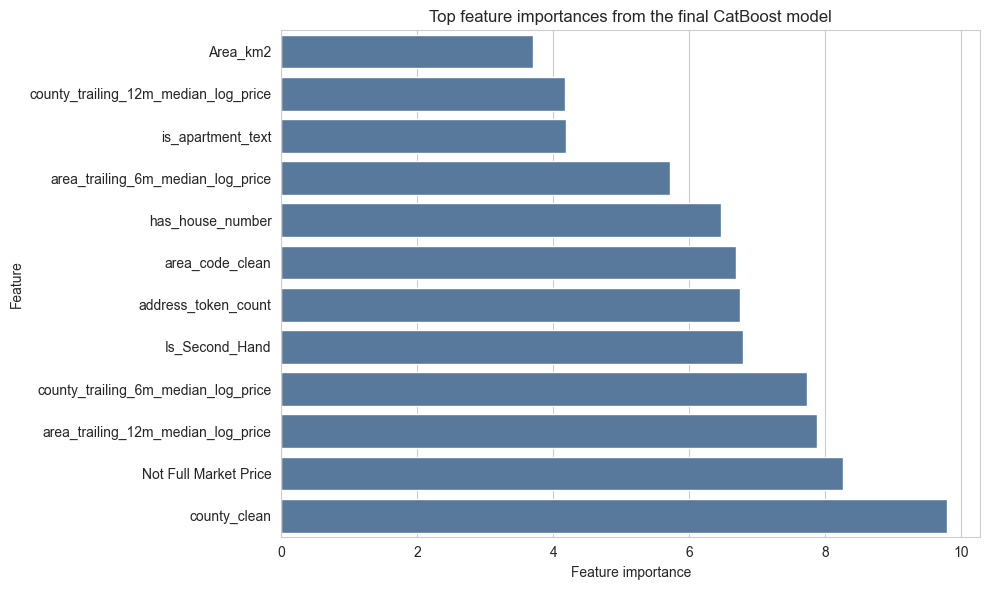

Importance grouped by feature block


,feature_group,n_features_present,total_importance,importance_pct
0,Internal engineered features,9,46.58,46.58
1,Core cleaned features,6,35.10,35.10
2,External engineered features,9,18.32,18.32


Top 5 most important features: county_clean, Not Full Market Price, area_trailing_12m_median_log_price, county_trailing_6m_median_log_price, Is_Second_Hand


In [43]:
def interpret_final_model(final_model, feature_cols, top_n=12):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': final_model.get_feature_importance(),
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    feature_importance['importance_pct'] = (
        feature_importance['importance'] / feature_importance['importance'].sum() * 100
    )

    top_features = feature_importance.head(top_n).copy()

    print('Final model feature importance ranking')
    display(feature_importance)

    plt.figure(figsize=(10, 6))
    if USE_SEABORN:
        sns.barplot(data=top_features.sort_values('importance', ascending=True), x='importance', y='feature', color='#4C78A8')
    else:
        plt.barh(top_features.sort_values('importance', ascending=True)['feature'], top_features.sort_values('importance', ascending=True)['importance'], color='#4C78A8')

    plt.title('Top feature importances from the final CatBoost model')
    plt.xlabel('Feature importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    importance_groups = {
        'Core cleaned features': [
            'Not Full Market Price',
            'county_clean',
            'area_code_clean',
            'Is_Second_Hand',
            'sale_year',
            'sale_month',
        ],
        'Internal engineered features': [
            'is_apartment_text',
            'has_estate_term',
            'has_rural_term',
            'has_house_number',
            'address_token_count',
            'county_trailing_6m_median_log_price',
            'county_trailing_12m_median_log_price',
            'area_trailing_6m_median_log_price',
            'area_trailing_12m_median_log_price',
        ],
        'External engineered features': [
            'County_New_Dwellings',
            'Area_New_Dwellings',
            'Mortgage Interest Rate',
            'Population',
            'Area_km2',
            'County_Area_km2',
            'County_Population_Density',
            'County_New_Dwellings_Density',
            'Area_New_Dwellings_Density',
        ],
    }

    group_rows = []
    for group_name, group_features in importance_groups.items():
        present_features = [feature for feature in group_features if feature in feature_importance['feature'].values]
        group_importance = feature_importance.loc[feature_importance['feature'].isin(present_features), 'importance'].sum()
        group_rows.append({
            'feature_group': group_name,
            'n_features_present': len(present_features),
            'total_importance': group_importance,
        })

    importance_by_group = pd.DataFrame(group_rows).sort_values('total_importance', ascending=False).reset_index(drop=True)
    importance_by_group['importance_pct'] = (
        importance_by_group['total_importance'] / importance_by_group['total_importance'].sum() * 100
    )

    print('Importance grouped by feature block')
    display(importance_by_group)

    top_5 = top_features.head(5)['feature'].tolist()
    print('Top 5 most important features:', ', '.join(top_5))

    return feature_importance, importance_by_group


feature_importance, importance_by_group = interpret_final_model(
    final_model=final_model,
    feature_cols=feature_cols,
    top_n=12,
)

The feature-importance results make the final model easier to explain. The strongest single driver is `county_clean`, followed by `Not Full Market Price`, the trailing area and county price-history features, and `Is_Second_Hand`. This matches the earlier pairwise analysis, where geography and dwelling type already appeared to be the most useful signals. It also shows that recent local price history is important, which is consistent with the time-based structure of the market.

At block level, the internal engineered features account for the largest share of total importance, the core cleaned features remain very strong, and the external engineered block contributes a smaller but still meaningful share. That is broadly consistent with the modelling results: external features helped modestly, while some internal features added useful signal but did not guarantee better holdout performance in every combination. The main conclusion is that the final model relies most on geography, transaction context, and recent local price trends, while the external macro and density variables act as secondary supporting signals.

We evaluated the CatBoost model on the full training set, with time-series cross-validation, and on the final holdout test set. Performance is strongest on the training set, lower on cross-validation, and lower again on the holdout test set, which suggests moderate overfitting. However, both cross-validation and test performance remain clearly better than the baseline model, so the model is still learning useful predictive structure. The gap between log-scale and euro-scale performance also shows that extreme high-value properties remain difficult to predict accurately on the raw euro scale.

## Appendix: Example of a Geocoding Approach Considered but Not Used

# Showcasing google API requests:
Using google API we were able to get further infromation I will attach example json. Which we got from using Cleaned Address using request from Google Maps (with an API key).

Example Response:
{'results': [{'address_components': [{'long_name': '7',
     'short_name': '7',
     'types': ['street_number']},
    {'long_name': 'Marlton Demesne',
     'short_name': 'Marlton Demesne',
     'types': ['route']},
    {'long_name': 'Ballynerrin',
     'short_name': 'Ballynerrin',
     'types': ['neighborhood', 'political']},
    {'long_name': 'Wicklow',
     'short_name': 'Wicklow',
     'types': ['locality', 'political']},
    {'long_name': 'County Wicklow',
     'short_name': 'WW',
     'types': ['administrative_area_level_1', 'political']},
    {'long_name': 'Ireland',
     'short_name': 'IE',
     'types': ['country', 'political']},
    {'long_name': 'A67 F853',
     'short_name': 'A67 F853',
     'types': ['postal_code']}],
   'formatted_address': '7 Marlton Demesne, Ballynerrin, Wicklow, A67 F853, Ireland',
   'geometry': {'bounds': {'northeast': {'lat': 52.9787057, 'lng': -6.0546202},
     'southwest': {'lat': 52.9785978, 'lng': -6.0548231}},
    'location': {'lat': 52.9786517, 'lng': -6.0547216},
    'location_type': 'ROOFTOP',
    'viewport': {'northeast': {'lat': 52.9800666802915,
      'lng': -6.053372669708497},
     'southwest': {'lat': 52.9773687197085, 'lng': -6.056070630291502}}},
   'navigation_points': [{'location': {'latitude': 52.9787746,
      'longitude': -6.0547222}}],
   'partial_match': True,
   'place_id': 'ChIJKYAhRrOwZ0gRS4sA6WtqkUI',
   'types': ['premise', 'street_address']}],
 'status': 'OK'}

 However, because this Group Project requires a static datasets, we decided not to use it, but in future for the model improvement this would be a great addition, as it will get rid of a lot of uncertainty we had with the dataset. And it will give extra infrormation that could be used for finding the size features as this would explain the price variation the most.

 